**Table of contents**<a id='toc0_'></a>    
- 1. [Project Summary](#toc1_)    
- 2. [Problem Statement](#toc2_)    
  - 2.1. [Business Context](#toc2_1_)    
  - 2.2. [Objective](#toc2_2_)    
  - 2.3. [Data Description](#toc2_3_)    
    - 2.3.1. [Customer Details](#toc2_3_1_)    
    - 2.3.2. [Customer Interaction Data](#toc2_3_2_)    
- 3. [Importing the necessary libraries](#toc3_)    
- 4. [Loading the required data](#toc4_)    
- 5. [Data cleaning](#toc5_)    
  - 5.1. [Checking for missing values](#toc5_1_)    
  - 5.2. [Checking for duplicate values](#toc5_2_)    
  - 5.3. [Checking for outliers](#toc5_3_)    
- 6. [Exploratory Data Analysis (EDA)](#toc6_)    
  - 6.1. [Univariate Analysis  - Numeric variables](#toc6_1_)    
  - 6.2. [Univariate Analysis - Non-numeric variables](#toc6_2_)    
  - 6.3. [Multivariate Analysis](#toc6_3_)    
    - 6.3.1. [Multivariate Analysis - Numeric variables](#toc6_3_1_)    
      - 6.3.1.1. [ProdTaken vs Age](#toc6_3_1_1_)    
      - 6.3.1.2. [ProdTaken vs CityTier](#toc6_3_1_2_)    
      - 6.3.1.3. [ProdTaken vs DurationOfPitch](#toc6_3_1_3_)    
      - 6.3.1.4. [ProdTaken vs NumberOfPersonVisiting](#toc6_3_1_4_)    
      - 6.3.1.5. [ProdTaken vs NumberOfFollowups](#toc6_3_1_5_)    
      - 6.3.1.6. [ProdTaken vs PreferredPropertyStar](#toc6_3_1_6_)    
      - 6.3.1.7. [ProdTaken vs NumberOfTrips](#toc6_3_1_7_)    
      - 6.3.1.8. [ProdTaken vs Passport](#toc6_3_1_8_)    
      - 6.3.1.9. [ProdTaken vs PitchSatisfactionScore](#toc6_3_1_9_)    
      - 6.3.1.10. [ProdTaken vs OwnCar](#toc6_3_1_10_)    
      - 6.3.1.11. [ProdTaken vs NumberOfChildrenVisiting](#toc6_3_1_11_)    
      - 6.3.1.12. [ProdTaken vs MonthlyIncome](#toc6_3_1_12_)    
  - 6.4. [Multivariate Analysis - Non-numeric variables](#toc6_4_)    
    - 6.4.1. [ProdTaken vs TypeofContact](#toc6_4_1_)    
    - 6.4.2. [ProdTaken vs Occupation](#toc6_4_2_)    
    - 6.4.3. [ProdTaken vs Gender](#toc6_4_3_)    
    - 6.4.4. [ProdTaken vs ProductPitched](#toc6_4_4_)    
    - 6.4.5. [ProdTaken vs MaritalStatus](#toc6_4_5_)    
    - 6.4.6. [ProdTaken vs Designation](#toc6_4_6_)    
      - 6.4.6.1. [Correlation matrix](#toc6_4_6_1_)    
        - 6.4.6.1.1. [Continous & Discreet Variables](#toc6_4_6_1_1_)    
        - 6.4.6.1.2. [Categorical Variables](#toc6_4_6_1_2_)    
- 7. [Feature Engineering](#toc7_)    
  - 7.1. [Encoding categorical variables](#toc7_1_)    
- 8. [Data splitting](#toc8_)    
  - 8.1. [Splitting data into Training, Validation and Test sets](#toc8_1_)    
- 9. [Model Training and Registration with Eperimentation Tracking](#toc9_)    
- 10. [Deployment](#toc10_)    
  - 10.1. [Dockerfile](#toc10_1_)    
  - 10.2. [Streamlit App](#toc10_2_)    
  - 10.3. [Dependency Handling](#toc10_3_)    
  - 10.4. [Hosting](#toc10_4_)    
- 11. [MLOps Pipeline with Github Action Workflow](#toc11_)    
  - 11.1. [Requirements file for the github Actions Workflow](#toc11_1_)    
  - 11.2. [Github Authentication and Push files](#toc11_2_)    
- 12. [Output Evaluation](#toc12_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[Project Summary](#toc0_)

This project predicts historical tourism-package purchases for **Visit with Us** at two decision points: pre-contact (13 profile features) and post-interaction (18 features). Travel preferences are assumed known before outreach.

The course-approved workflow uses **GitHub + GitHub Actions + Streamlit Community Cloud** instead of Hugging Face. GitHub versions raw/prepared datasets; MLflow records parameter searches; GitHub Releases register verified models; a gated deployment branch supplies the app.

The production pipeline removes duplicate records and identifier columns, keeps customer groups in one partition, fits all imputers/encoders inside training folds, and selects decision thresholds using validation data only. The final test set is reserved for reporting.

Historical purchases are a proxy for the new wellness offering. The dataset has no timestamps to verify feature availability relative to purchase, so results are not a causal or prospective validation. Live deployment URLs and screenshots are tracked in `docs/submission.md`; local results do not imply that deployment is complete.

# 2. <a id='toc2_'></a>[Problem Statement](#toc0_)

## 2.1. <a id='toc2_1_'></a>[Business Context](#toc0_)

**Visit with Us** is a leading travel company using data-driven strategies to improve operations and customer engagement. With the launch of a new **Wellness Tourism Package**, the company needs to identify customers who are most likely to make a purchase.

The current manual process is:

- Time-consuming
- Inconsistent
- Prone to human error
- Inefficient for large-scale customer targeting

To address these challenges, the company plans to develop an automated machine learning system that integrates customer data, predicts purchase behavior, and supports data-driven marketing decisions.

## 2.2. <a id='toc2_2_'></a>[Objective](#toc0_)

As an MLOps Engineer, the objective is to design and deploy an end-to-end MLOps pipeline for predicting whether a customer will purchase the Wellness Tourism Package.

The pipeline will include:

1. Data cleaning and preprocessing
2. Feature transformation and engineering
3. Model development and training
4. Model evaluation
5. Model deployment
6. Experiment tracking
7. CI/CD automation using GitHub Actions

This solution will help **Visit with Us** improve customer targeting, optimize marketing campaigns, automate model updates, and increase customer acquisition.

## 2.3. <a id='toc2_3_'></a>[Data Description](#toc0_)

The dataset contains customer demographics, preferences, and sales-interaction information. The target variable is `ProdTaken`, which indicates whether the customer purchased a tourism package.

### 2.3.1. <a id='toc2_3_1_'></a>[Customer Details](#toc0_)

| Feature | Description |
|---|---|
| `CustomerID` | Unique customer identifier |
| `ProdTaken` | Package purchase indicator: `0` = No, `1` = Yes |
| `Age` | Customer's age |
| `TypeofContact` | Contact method: Company Invited or Self Enquiry |
| `CityTier` | City classification based on development and living standards |
| `Occupation` | Customer's occupation |
| `Gender` | Customer's gender |
| `NumberOfPersonVisiting` | Number of people accompanying the customer |
| `PreferredPropertyStar` | Customer's preferred hotel rating |
| `MaritalStatus` | Customer's marital status |
| `NumberOfTrips` | Average number of annual trips |
| `Passport` | Passport ownership: `0` = No, `1` = Yes |
| `OwnCar` | Car ownership: `0` = No, `1` = Yes |
| `NumberOfChildrenVisiting` | Number of accompanying children below age five |
| `Designation` | Customer's current organizational designation |
| `MonthlyIncome` | Customer's gross monthly income |

### 2.3.2. <a id='toc2_3_2_'></a>[Customer Interaction Data](#toc0_)

| Feature | Description |
|---|---|
| `PitchSatisfactionScore` | Customer's satisfaction with the sales pitch |
| `ProductPitched` | Type of product presented to the customer |
| `NumberOfFollowups` | Number of follow-ups made after the sales pitch |
| `DurationOfPitch` | Duration of the sales pitch |

# 3. <a id='toc3_'></a>[Importing the necessary libraries](#toc0_)

In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Code, Image, Markdown, display
from sklearn.ensemble import RandomForestClassifier

from wellness_tourism.data import load_prepared, prepare_dataset, sha256
from wellness_tourism.modeling import build_pipeline
from wellness_tourism.schema import CATEGORICAL, FEATURES, TARGET

assert sys.version_info[:2] == (3, 12), "Select the project's Python 3.12 .venv-win kernel."
config = json.loads(Path('config.json').read_text())
# Legacy EDA plots use deprecated seaborn options; model warnings remain visible.
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')
print('Interpreter:', sys.executable)
print('Workflow: GitHub + GitHub Actions + Streamlit Community Cloud')

Interpreter: /opt/hostedtoolcache/Python/3.12.14/x64/bin/python
Workflow: GitHub + GitHub Actions + Streamlit Community Cloud


# 4. <a id='toc4_'></a>[Loading the required data](#toc0_)

In [2]:
# In CI this is the raw dataset checked out at the exact GitHub source revision.
# Preparation records hashes and saves independently reproducible train/test CSVs.
data_manifest = prepare_dataset(config)
df = pd.read_csv(config['data_path'])
print('Registered SHA-256:', data_manifest['source_sha256'])
print('Raw rows:', data_manifest['rows_raw'])
print('Duplicate records removed for modeling:', data_manifest['duplicates_removed'])
df.head()

Registered SHA-256: 3173923f1baad22ab115b7367713663f92a49d488411c1190180932b1a58bba3
Raw rows: 4128
Duplicate records removed for modeling: 117


,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,...,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,0,200000,1,41,Self Enquiry,3,6,Salaried,Female,3,...,Deluxe,3,Single,1,1,2,1,0,Manager,20993
1,1,200001,0,49,Company Invited,1,14,Salaried,Male,3,...,Deluxe,4,Divorced,2,0,3,1,2,Manager,20130
2,2,200002,1,37,Self Enquiry,1,8,Free Lancer,Male,3,...,Basic,3,Single,7,1,3,0,0,Executive,17090
3,3,200003,0,33,Company Invited,1,9,Salaried,Female,2,...,Basic,3,Divorced,2,1,5,1,1,Executive,17909
4,5,200005,0,32,Company Invited,1,8,Salaried,Male,3,...,Basic,3,Single,1,0,5,1,1,Executive,18068


In [3]:
# Checking the shape of the dataset
df.shape

(4128, 21)

In [4]:
# Viewing the first 5 rows of the dataset
df.head()

,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,...,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,0,200000,1,41,Self Enquiry,3,6,Salaried,Female,3,...,Deluxe,3,Single,1,1,2,1,0,Manager,20993
1,1,200001,0,49,Company Invited,1,14,Salaried,Male,3,...,Deluxe,4,Divorced,2,0,3,1,2,Manager,20130
2,2,200002,1,37,Self Enquiry,1,8,Free Lancer,Male,3,...,Basic,3,Single,7,1,3,0,0,Executive,17090
3,3,200003,0,33,Company Invited,1,9,Salaried,Female,2,...,Basic,3,Divorced,2,1,5,1,1,Executive,17909
4,5,200005,0,32,Company Invited,1,8,Salaried,Male,3,...,Basic,3,Single,1,0,5,1,1,Executive,18068


In [5]:
# Viewing the last 5 rows of the dataset
df.tail()

,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,...,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
4123,4883,204883,1,49,Self Enquiry,3,9,Small Business,Male,3,...,Deluxe,4,Unmarried,2,1,1,1,1,Manager,26576
4124,4884,204884,1,28,Company Invited,1,31,Salaried,Male,4,...,Basic,3,Single,3,1,3,1,2,Executive,21212
4125,4885,204885,1,52,Self Enquiry,3,17,Salaried,Female,4,...,Standard,4,Married,7,0,1,1,3,Senior Manager,31820
4126,4886,204886,1,19,Self Enquiry,3,16,Small Business,Male,3,...,Basic,3,Single,3,0,5,0,2,Executive,20289
4127,4887,204887,1,36,Self Enquiry,1,14,Salaried,Male,4,...,Basic,4,Unmarried,3,1,3,1,2,Executive,24041


In [6]:
# Checking the data types of each column in the dataset
df.dtypes

Unnamed: 0                   int64
CustomerID                   int64
ProdTaken                    int64
Age                          int64
TypeofContact               object
CityTier                     int64
DurationOfPitch              int64
Occupation                  object
Gender                      object
NumberOfPersonVisiting       int64
NumberOfFollowups            int64
ProductPitched              object
PreferredPropertyStar        int64
MaritalStatus               object
NumberOfTrips                int64
Passport                     int64
PitchSatisfactionScore       int64
OwnCar                       int64
NumberOfChildrenVisiting     int64
Designation                 object
MonthlyIncome                int64
dtype: object

In [7]:
# EDA remains separate from the prepared model data and may contain plot-only bands.
# Retain duplicates here so the quality check below shows what preparation removed.
from wellness_tourism.schema import normalize_features

df2 = normalize_features(df, 'post_interaction')
df2[TARGET] = df[TARGET].astype(int)
df2.head()

,Age,CityTier,Occupation,Gender,NumberOfPersonVisiting,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,TypeofContact,DurationOfPitch,NumberOfFollowups,ProductPitched,PitchSatisfactionScore,ProdTaken
0,41.0,3.0,Salaried,Female,3.0,3.0,Single,1.0,1.0,1.0,0.0,Manager,20993.0,Self Enquiry,6.0,3.0,Deluxe,2.0,1
1,49.0,1.0,Salaried,Male,3.0,4.0,Divorced,2.0,0.0,1.0,2.0,Manager,20130.0,Company Invited,14.0,4.0,Deluxe,3.0,0
2,37.0,1.0,Free Lancer,Male,3.0,3.0,Single,7.0,1.0,0.0,0.0,Executive,17090.0,Self Enquiry,8.0,4.0,Basic,3.0,1
3,33.0,1.0,Salaried,Female,2.0,3.0,Divorced,2.0,1.0,1.0,1.0,Executive,17909.0,Company Invited,9.0,3.0,Basic,5.0,0
4,32.0,1.0,Salaried,Male,3.0,3.0,Single,1.0,0.0,1.0,1.0,Executive,18068.0,Company Invited,8.0,3.0,Basic,5.0,0


In [8]:
# Statistical summary
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,4128.0,37.231831,9.174521,18.0,31.0,36.0,43.0,61.0
CityTier,4128.0,1.663275,0.920640,1.0,1.0,1.0,3.0,3.0
NumberOfPersonVisiting,4128.0,2.949370,0.718818,1.0,2.0,3.0,3.0,5.0
PreferredPropertyStar,4128.0,3.578488,0.795031,3.0,3.0,3.0,4.0,5.0
NumberOfTrips,4128.0,3.295300,1.856300,1.0,2.0,3.0,4.0,22.0
Passport,4128.0,0.295300,0.456233,0.0,0.0,0.0,1.0,1.0
OwnCar,4128.0,0.612161,0.487317,0.0,0.0,1.0,1.0,1.0
NumberOfChildrenVisiting,4128.0,1.223595,0.852685,0.0,1.0,1.0,2.0,3.0
MonthlyIncome,4128.0,23178.464147,4506.614622,1000.0,20751.0,22418.0,25301.0,98678.0
DurationOfPitch,4128.0,15.584787,8.398142,5.0,9.0,14.0,20.0,127.0


# 5. <a id='toc5_'></a>[Data cleaning](#toc0_)

## 5.1. <a id='toc5_1_'></a>[Checking for missing values](#toc0_)

In [9]:
df2.isnull().sum()

Age                         0
CityTier                    0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
TypeofContact               0
DurationOfPitch             0
NumberOfFollowups           0
ProductPitched              0
PitchSatisfactionScore      0
ProdTaken                   0
dtype: int64

## 5.2. <a id='toc5_2_'></a>[Checking for duplicate values](#toc0_)

In [10]:
df2.duplicated().sum()

np.int64(117)

## 5.3. <a id='toc5_3_'></a>[Checking for outliers](#toc0_)

In [11]:

numeric_data = df2.select_dtypes(include=[np.number])
Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

outlier_mask_lower =  (numeric_data < (Q1 - 1.5 * IQR)) 
outlier_mask_upper =  (numeric_data > (Q3 + 1.5 * IQR))

outlier_count_lower = outlier_mask_lower.sum()
outlier_count_upper = outlier_mask_upper.sum()

print("Number of outliers below lower bound:")
print(outlier_count_lower)
print("Number of outliers above upper bound:")
print(outlier_count_upper)

Number of outliers below lower bound:
Age                           0
CityTier                      0
NumberOfPersonVisiting        0
PreferredPropertyStar         0
NumberOfTrips                 0
Passport                      0
OwnCar                        0
NumberOfChildrenVisiting      0
MonthlyIncome                 2
DurationOfPitch               0
NumberOfFollowups           144
PitchSatisfactionScore        0
ProdTaken                     0
dtype: int64
Number of outliers above upper bound:
Age                           0
CityTier                      0
NumberOfPersonVisiting        3
PreferredPropertyStar         0
NumberOfTrips               107
Passport                      0
OwnCar                        0
NumberOfChildrenVisiting      0
MonthlyIncome               221
DurationOfPitch               1
NumberOfFollowups           124
PitchSatisfactionScore        0
ProdTaken                   797
dtype: int64


# 6. <a id='toc6_'></a>[Exploratory Data Analysis (EDA)](#toc0_)

## 6.1. <a id='toc6_1_'></a>[Univariate Analysis  - Numeric variables](#toc0_)

In [12]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [13]:
numeric_data.dtypes

Age                         float64
CityTier                    float64
NumberOfPersonVisiting      float64
PreferredPropertyStar       float64
NumberOfTrips               float64
Passport                    float64
OwnCar                      float64
NumberOfChildrenVisiting    float64
MonthlyIncome               float64
DurationOfPitch             float64
NumberOfFollowups           float64
PitchSatisfactionScore      float64
ProdTaken                     int64
dtype: object

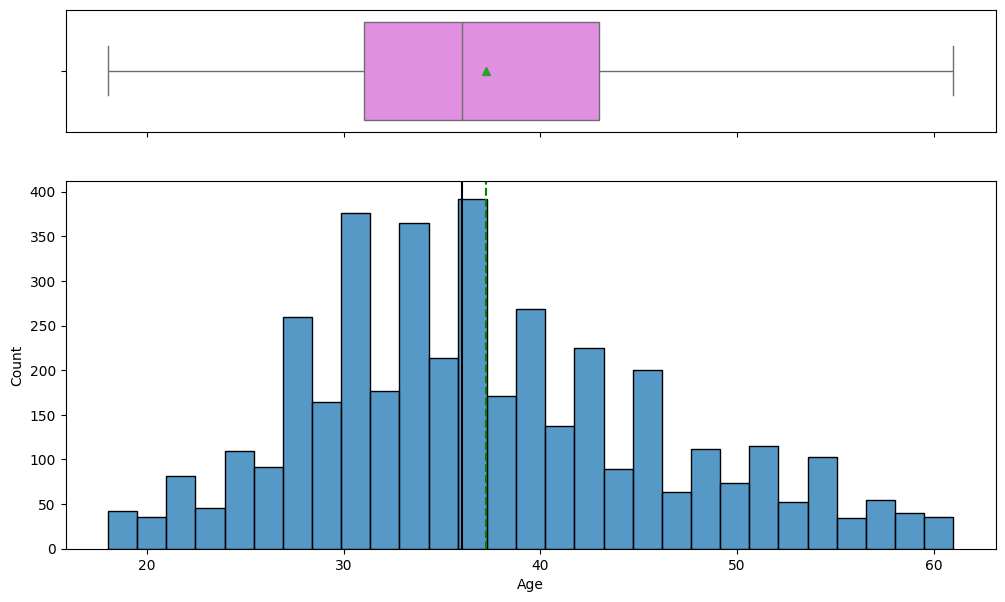

In [14]:
histogram_boxplot(df2, "Age")

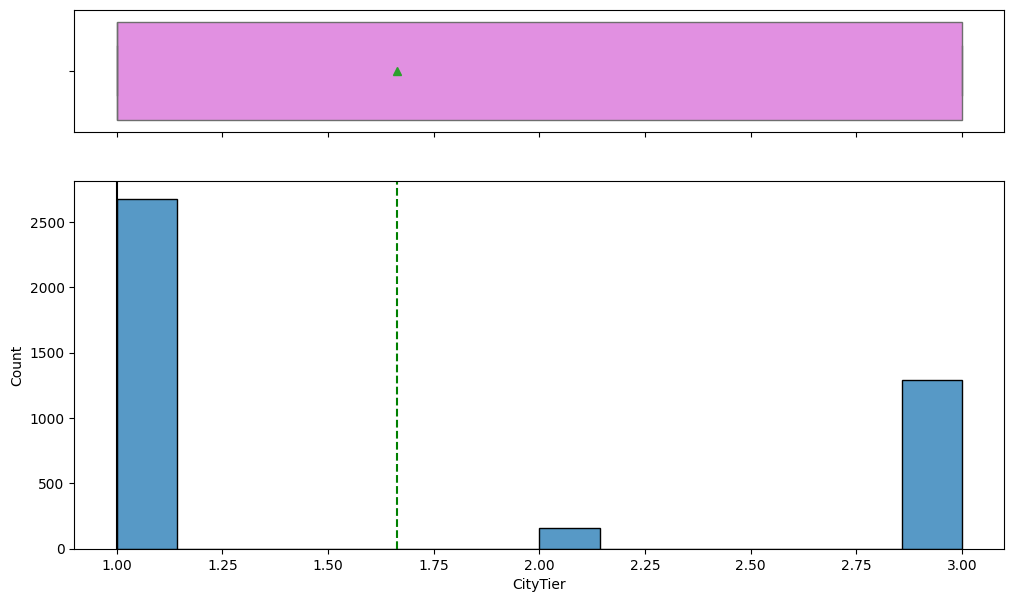

In [15]:
histogram_boxplot(df2, "CityTier")

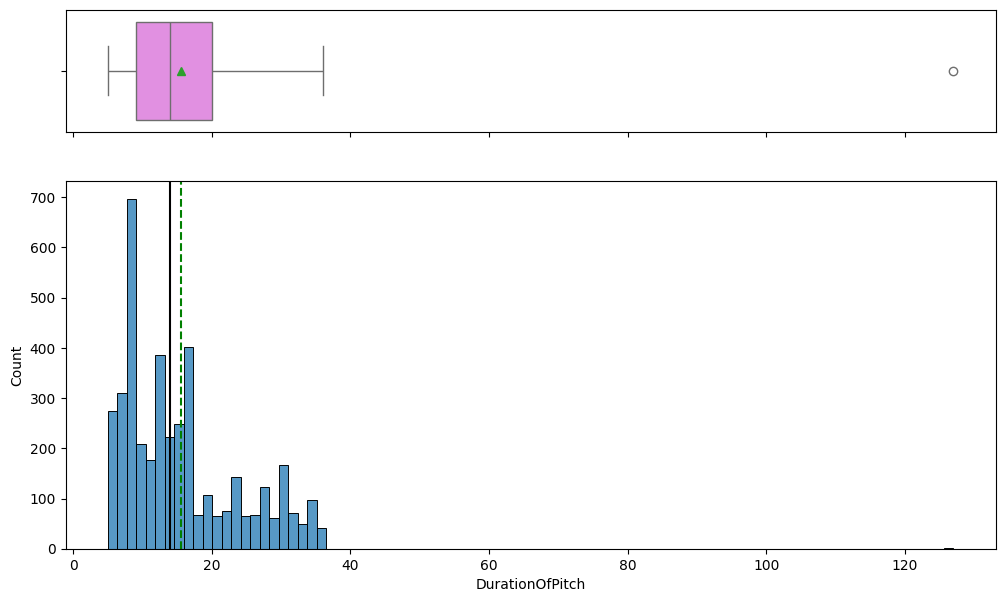

In [16]:
histogram_boxplot(df2, "DurationOfPitch")

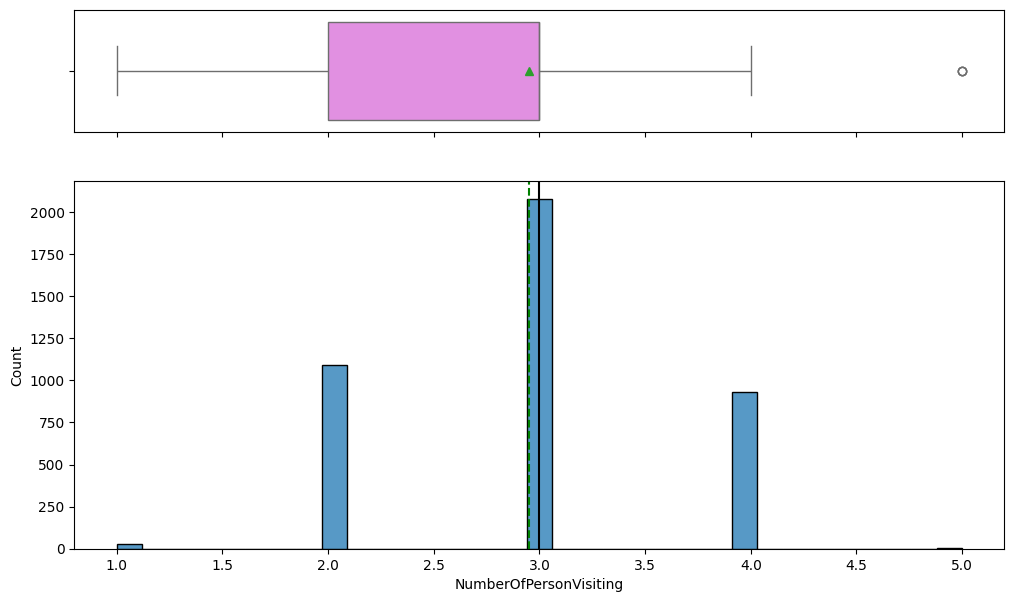

In [17]:
histogram_boxplot(df2, "NumberOfPersonVisiting")

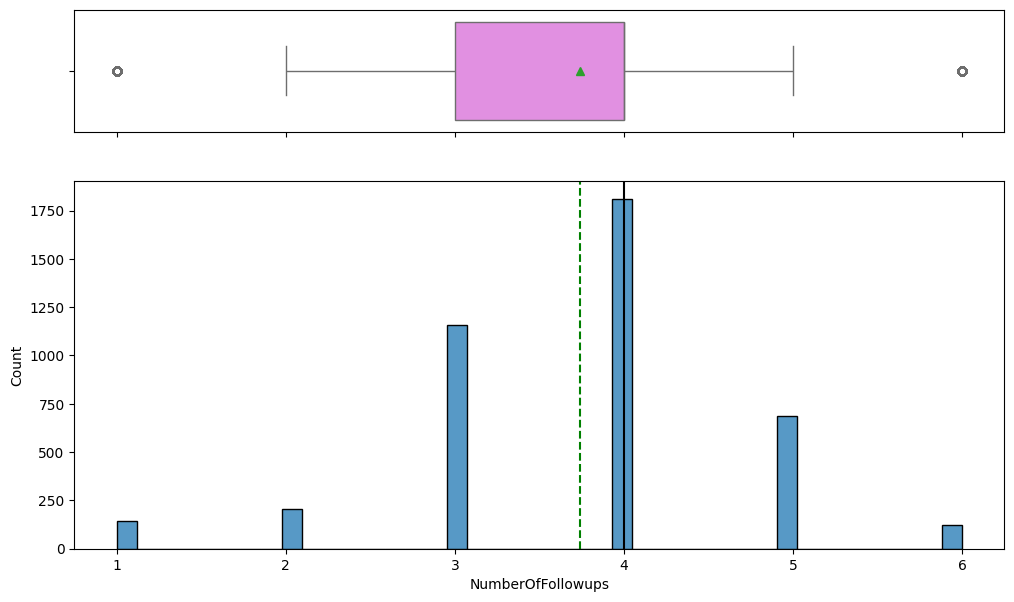

In [18]:
histogram_boxplot(df2, "NumberOfFollowups")

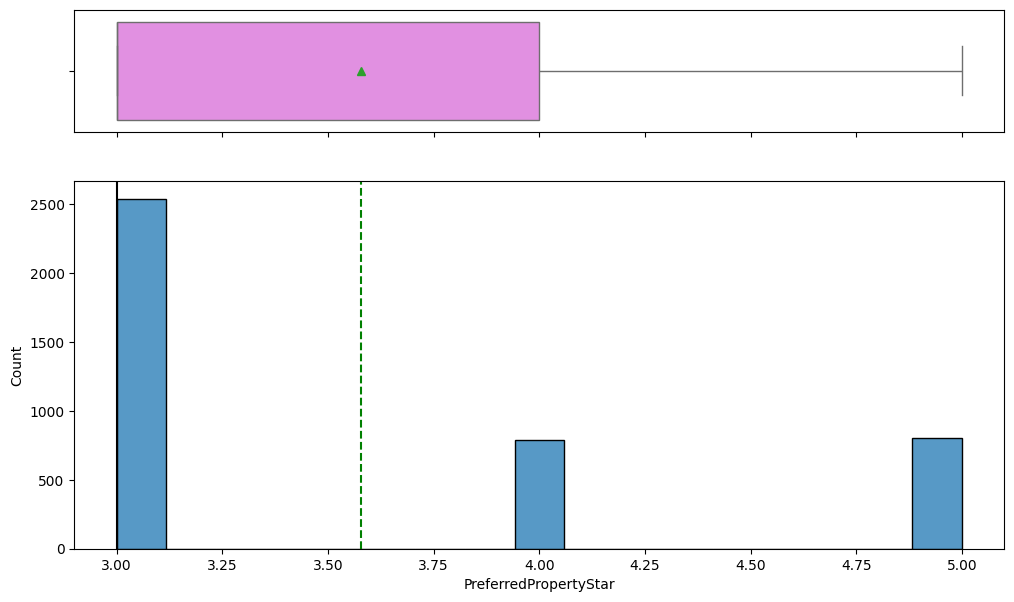

In [19]:
histogram_boxplot(df2, "PreferredPropertyStar")

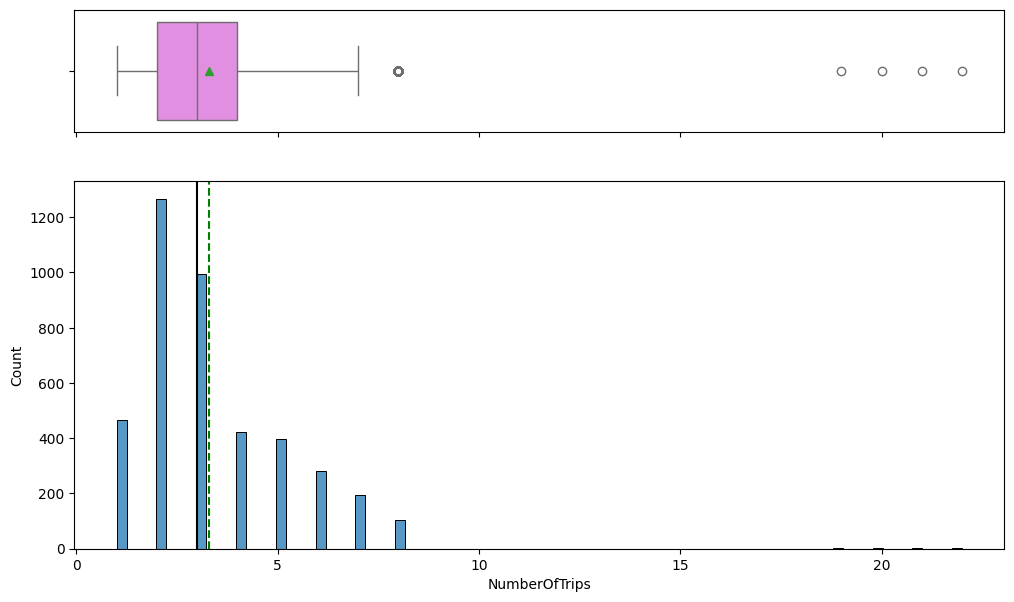

In [20]:
histogram_boxplot(df2, "NumberOfTrips")

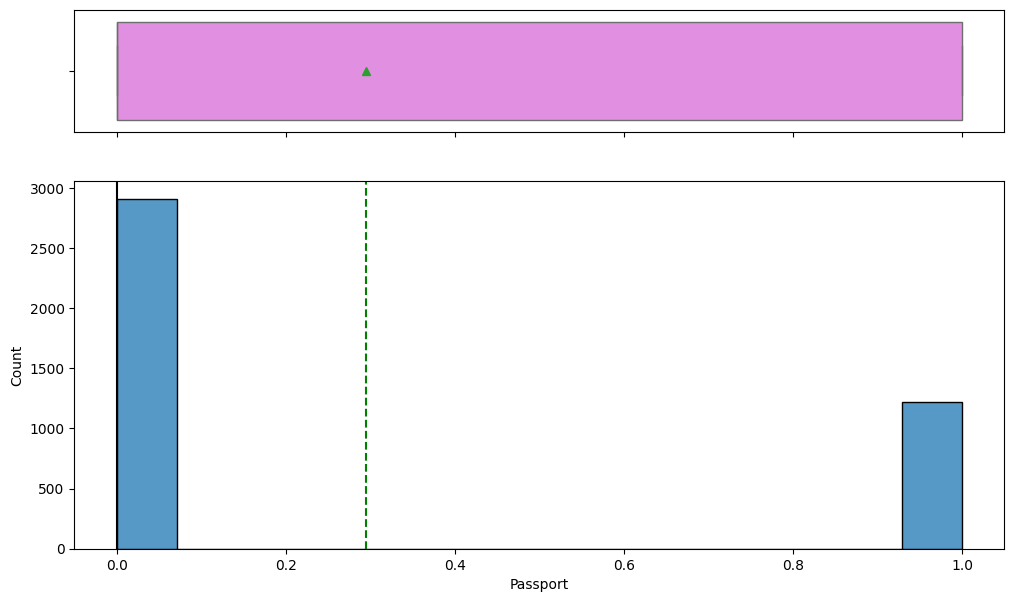

In [21]:
histogram_boxplot(df2, "Passport")

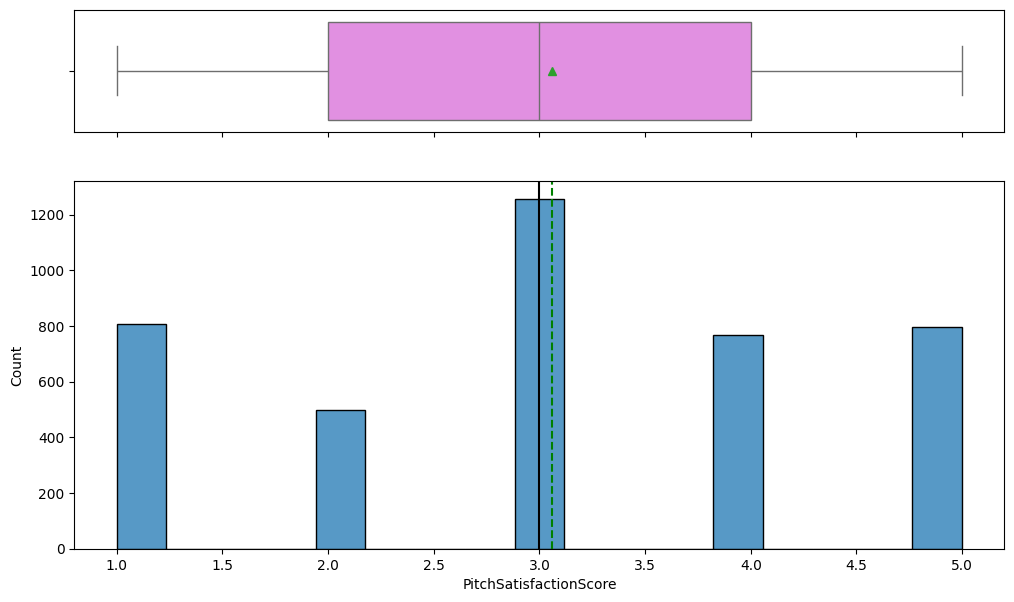

In [22]:
histogram_boxplot(df2, "PitchSatisfactionScore")

## 6.2. <a id='toc6_2_'></a>[Univariate Analysis - Non-numeric variables](#toc0_)

In [23]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None, count=False):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
        hue=feature,  # Assign x variable to hue
        legend=False  # Set legend to False
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [24]:
objects_data = df2.select_dtypes(include=['object'])
objects_data.dtypes

Occupation        object
Gender            object
MaritalStatus     object
Designation       object
TypeofContact     object
ProductPitched    object
dtype: object

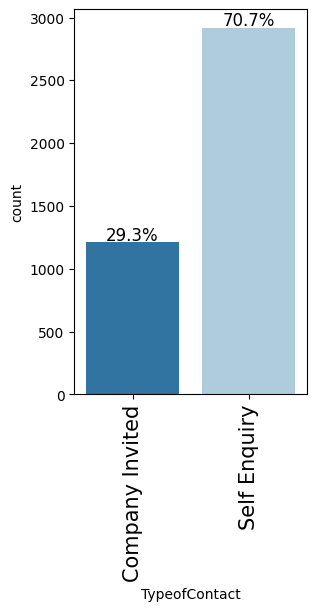

In [25]:
labeled_barplot(df2, "TypeofContact", perc= True)

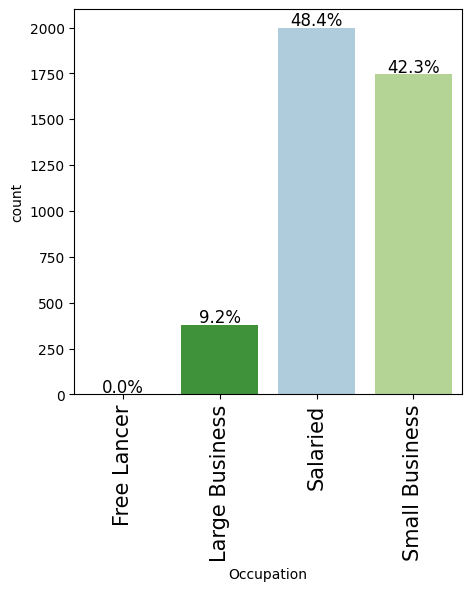

In [26]:
labeled_barplot(df2, "Occupation", perc= True)

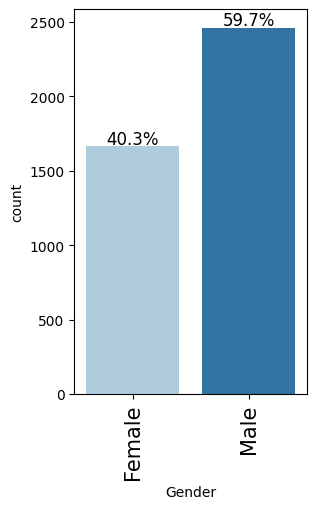

In [27]:
labeled_barplot(df2, "Gender", perc= True)

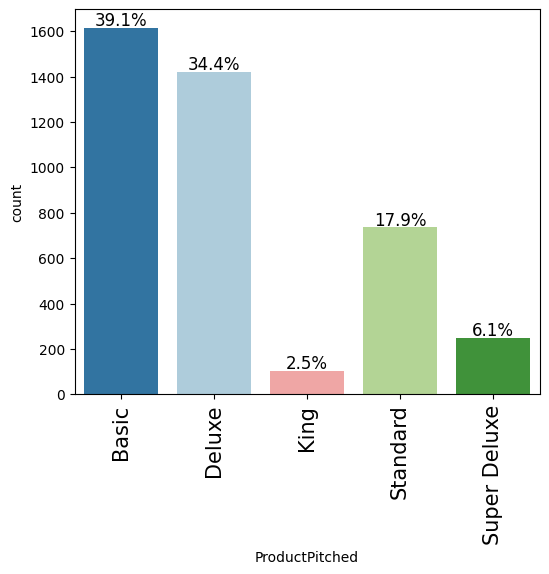

In [28]:
labeled_barplot(df2, "ProductPitched", perc= True)

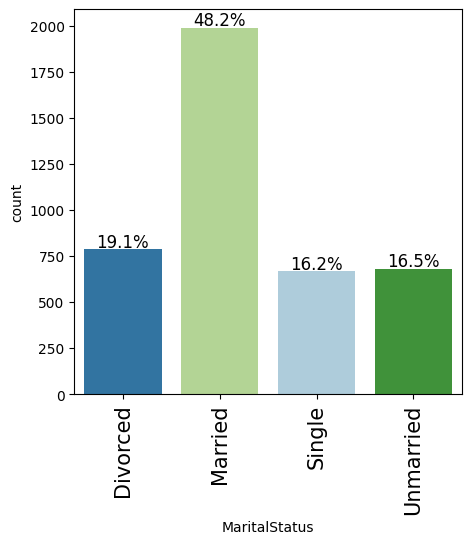

In [29]:
labeled_barplot(df2, "MaritalStatus", perc= True)

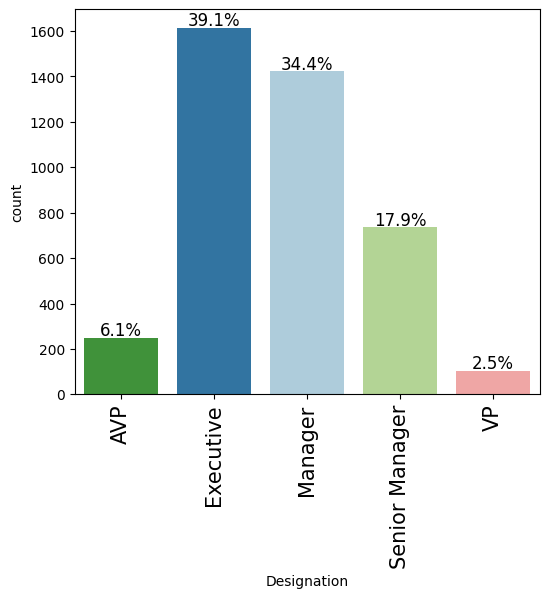

In [30]:
labeled_barplot(df2, "Designation", perc= True)

## 6.3. <a id='toc6_3_'></a>[Multivariate Analysis](#toc0_)

### 6.3.1. <a id='toc6_3_1_'></a>[Multivariate Analysis - Numeric variables](#toc0_)

In [31]:
numeric_data.dtypes

Age                         float64
CityTier                    float64
NumberOfPersonVisiting      float64
PreferredPropertyStar       float64
NumberOfTrips               float64
Passport                    float64
OwnCar                      float64
NumberOfChildrenVisiting    float64
MonthlyIncome               float64
DurationOfPitch             float64
NumberOfFollowups           float64
PitchSatisfactionScore      float64
ProdTaken                     int64
dtype: object

#### 6.3.1.1. <a id='toc6_3_1_1_'></a>[ProdTaken vs Age](#toc0_)

/tmp/ipykernel_2276/1606117280.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_rate = df2.groupby('AgeGroup')['ProdTaken'].mean().mul(100)
/tmp/ipykernel_2276/1606117280.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=age_group_rate.index, y=age_group_rate.values, palette="Set2")


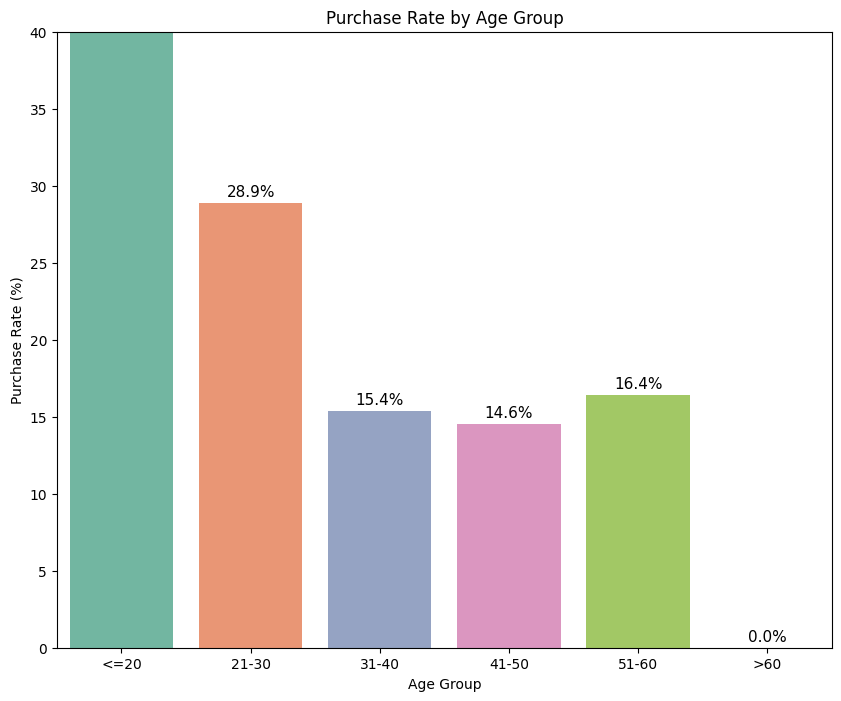

In [32]:
# Create age groups
df2['AgeGroup'] = pd.cut(
    df2['Age'],
    bins=[0, 20, 30, 40, 50, 60, 100],
    labels=['<=20', '21-30', '31-40', '41-50', '51-60', '>60']
)

# Purchase rate by age group
age_group_rate = df2.groupby('AgeGroup')['ProdTaken'].mean().mul(100)

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=age_group_rate.index, y=age_group_rate.values, palette="Set2")

plt.title("Purchase Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Purchase Rate (%)")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=11
    )

plt.ylim(0, 40)
plt.show()

/tmp/ipykernel_2276/2038923237.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df2, x='ProdTaken', y='Age', palette='Set2')
/tmp/ipykernel_2276/2038923237.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Purchased', 'Purchased'])


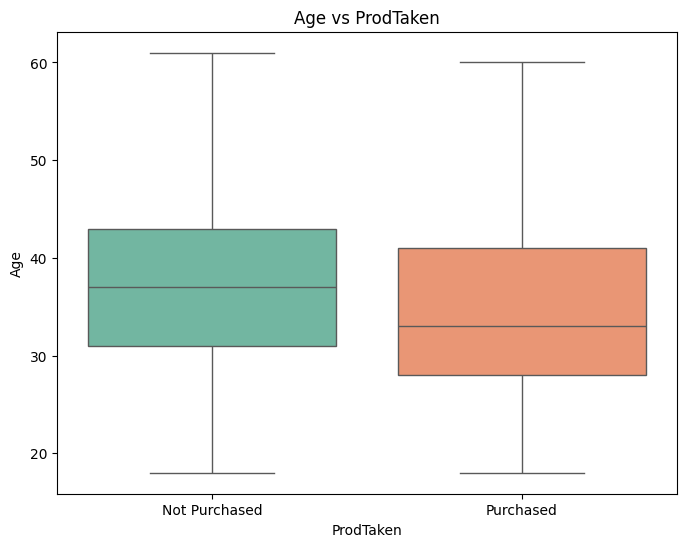

In [33]:
plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=df2, x='ProdTaken', y='Age', palette='Set2')
plt.title('Age vs ProdTaken')
plt.xlabel('ProdTaken')
plt.ylabel('Age')
ax.set_xticklabels(['Not Purchased', 'Purchased'])
plt.show()

#### 6.3.1.2. <a id='toc6_3_1_2_'></a>[ProdTaken vs CityTier](#toc0_)

/tmp/ipykernel_2276/3518310250.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=city_tier_rate.index, y=city_tier_rate.values, palette="Blues")


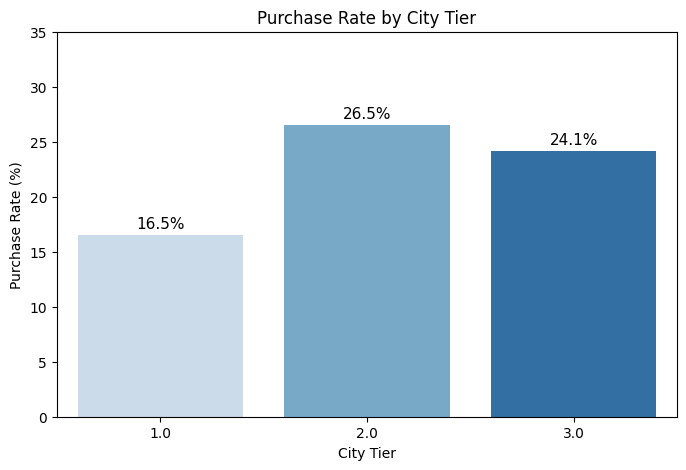

In [34]:
# Purchase rate by CityTier
city_tier_rate = df2.groupby('CityTier')['ProdTaken'].mean().mul(100)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=city_tier_rate.index, y=city_tier_rate.values, palette="Blues")

plt.title("Purchase Rate by City Tier")
plt.xlabel("City Tier")
plt.ylabel("Purchase Rate (%)")

# Add percentage labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=11
    )

plt.ylim(0, 35)
plt.show()

Observations


#### 6.3.1.3. <a id='toc6_3_1_3_'></a>[ProdTaken vs DurationOfPitch](#toc0_)

/tmp/ipykernel_2276/2294663681.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df2, x='ProdTaken', y='DurationOfPitch', palette='Set2')


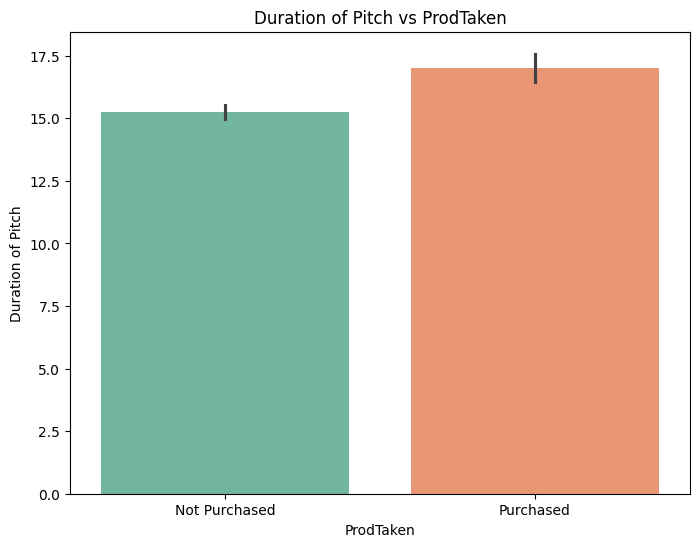

In [35]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df2, x='ProdTaken', y='DurationOfPitch', palette='Set2')
plt.title('Duration of Pitch vs ProdTaken')
plt.xlabel('ProdTaken')
plt.ylabel('Duration of Pitch')
plt.xticks([0, 1], ['Not Purchased', 'Purchased'])
plt.show()

/tmp/ipykernel_2276/432374987.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='ProdTaken', y='DurationOfPitch', palette='Set2')


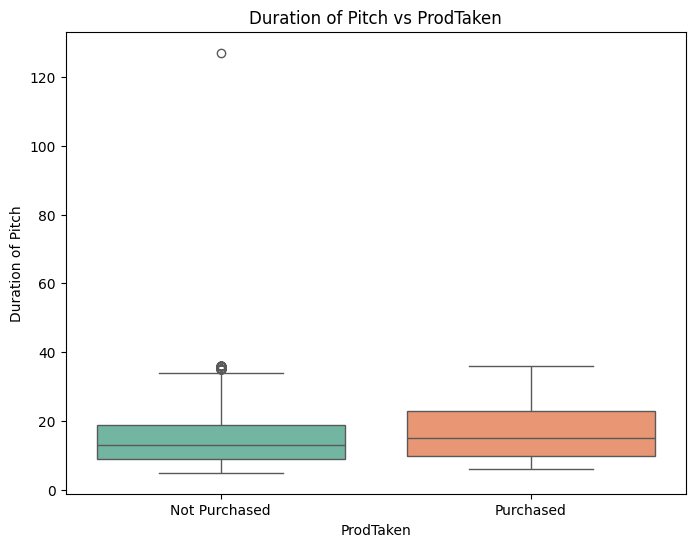

In [36]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df2, x='ProdTaken', y='DurationOfPitch', palette='Set2')
plt.title('Duration of Pitch vs ProdTaken')
plt.xlabel('ProdTaken')
plt.ylabel('Duration of Pitch')
plt.xticks([0, 1], ['Not Purchased', 'Purchased'])
plt.show()

#### 6.3.1.4. <a id='toc6_3_1_4_'></a>[ProdTaken vs NumberOfPersonVisiting](#toc0_)

/tmp/ipykernel_2276/1453273622.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=person_visit_rate.index, y=person_visit_rate.values, palette='Oranges')


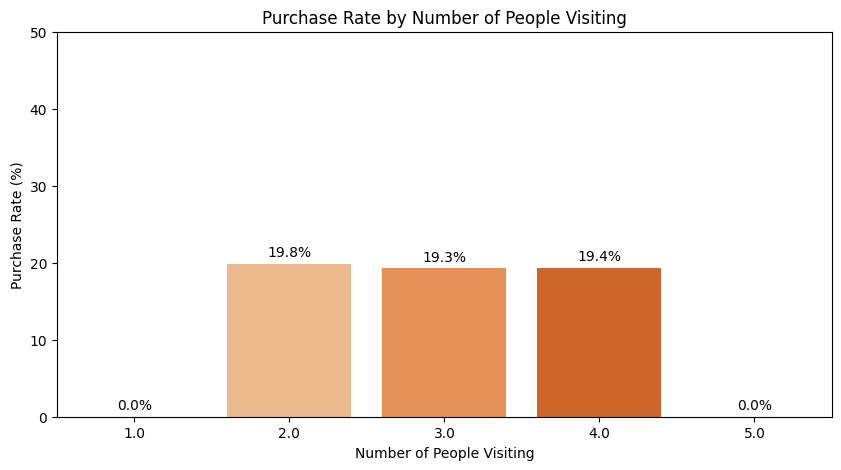

In [37]:
# Purchase rate by NumberOfPersonVisiting
person_visit_rate = df2.groupby('NumberOfPersonVisiting')['ProdTaken'].mean().mul(100)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=person_visit_rate.index, y=person_visit_rate.values, palette='Oranges')

plt.title('Purchase Rate by Number of People Visiting')
plt.xlabel('Number of People Visiting')
plt.ylabel('Purchase Rate (%)')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=10
    )

plt.ylim(0, 50)
plt.show()

/tmp/ipykernel_2276/646572676.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df2, x='ProdTaken', y='NumberOfPersonVisiting', palette='Set2')
/tmp/ipykernel_2276/646572676.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Purchased', 'Purchased'])


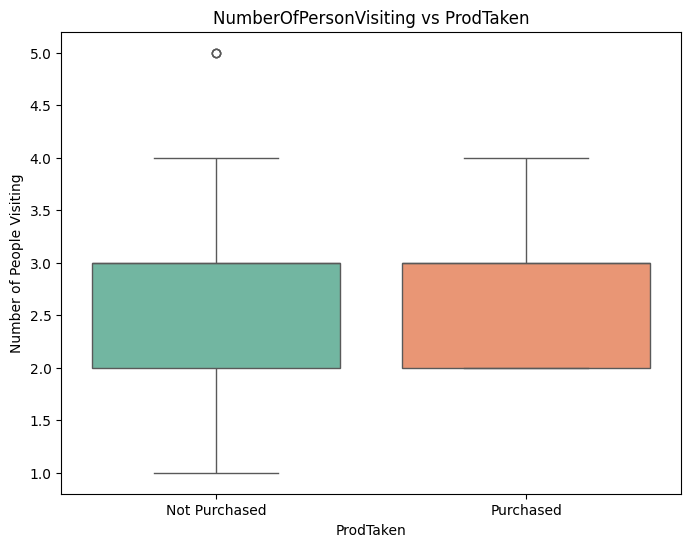

In [38]:
plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=df2, x='ProdTaken', y='NumberOfPersonVisiting', palette='Set2')
plt.title('NumberOfPersonVisiting vs ProdTaken')
plt.xlabel('ProdTaken')
plt.ylabel('Number of People Visiting')
ax.set_xticklabels(['Not Purchased', 'Purchased'])
plt.show()

#### 6.3.1.5. <a id='toc6_3_1_5_'></a>[ProdTaken vs NumberOfFollowups](#toc0_)

/tmp/ipykernel_2276/42900103.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=followup_rate.index, y=followup_rate.values, palette='Purples')


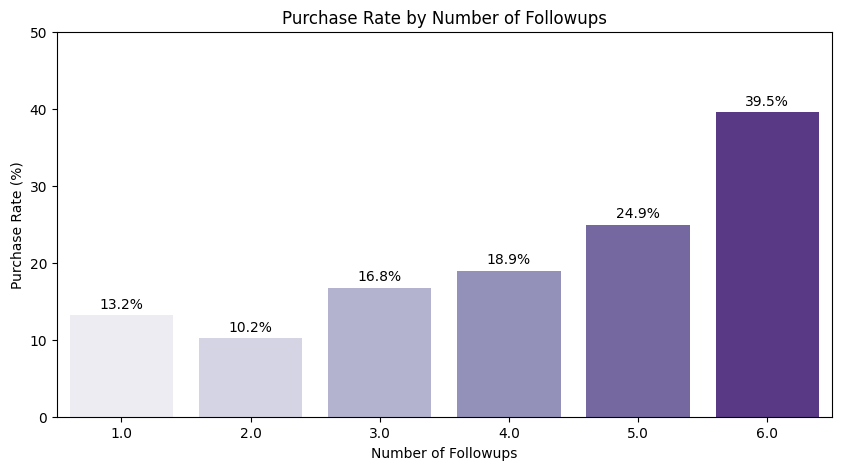

In [39]:
# Purchase rate by NumberOfFollowups
followup_rate = df2.groupby('NumberOfFollowups')['ProdTaken'].mean().mul(100)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=followup_rate.index, y=followup_rate.values, palette='Purples')

plt.title('Purchase Rate by Number of Followups')
plt.xlabel('Number of Followups')
plt.ylabel('Purchase Rate (%)')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=10
    )

plt.ylim(0, 50)
plt.show()

/tmp/ipykernel_2276/1188898045.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df2, x='ProdTaken', y='NumberOfFollowups', palette='Set2')
/tmp/ipykernel_2276/1188898045.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Purchased', 'Purchased'])


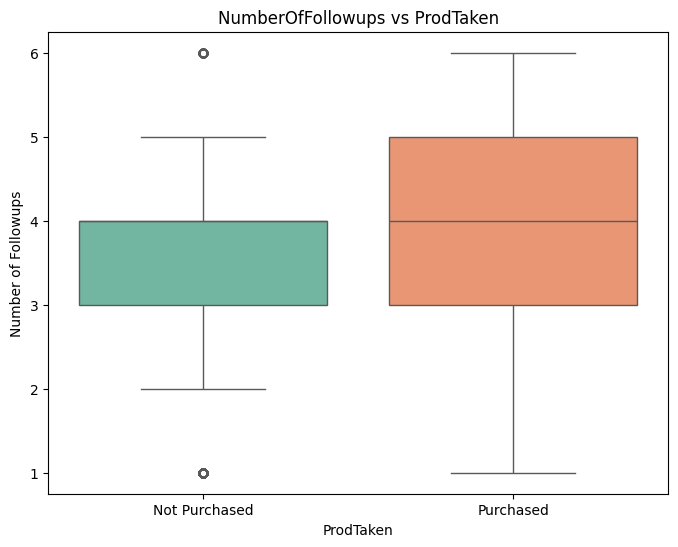

In [40]:
plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=df2, x='ProdTaken', y='NumberOfFollowups', palette='Set2')
plt.title('NumberOfFollowups vs ProdTaken')
plt.xlabel('ProdTaken')
plt.ylabel('Number of Followups')
ax.set_xticklabels(['Not Purchased', 'Purchased'])
plt.show()

#### 6.3.1.6. <a id='toc6_3_1_6_'></a>[ProdTaken vs PreferredPropertyStar](#toc0_)

/tmp/ipykernel_2276/2554502744.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=preferred_star_rate.index, y=preferred_star_rate.values, palette='Greens')


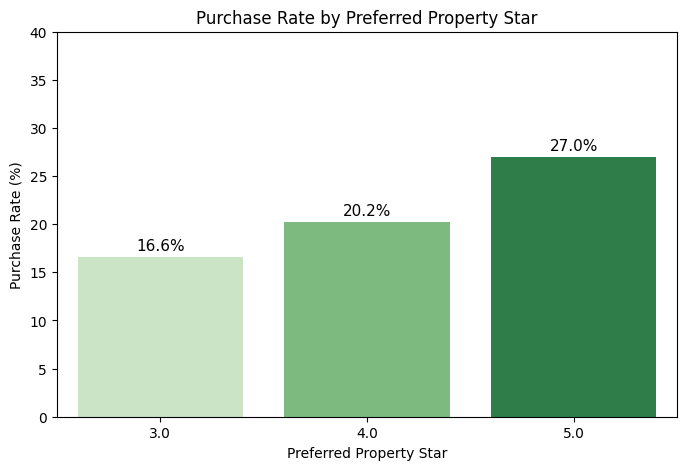

In [41]:
# Purchase rate by PreferredPropertyStar
preferred_star_rate = df2.groupby('PreferredPropertyStar')['ProdTaken'].mean().mul(100)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=preferred_star_rate.index, y=preferred_star_rate.values, palette='Greens')

plt.title('Purchase Rate by Preferred Property Star')
plt.xlabel('Preferred Property Star')
plt.ylabel('Purchase Rate (%)')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=11
    )

plt.ylim(0, 40)
plt.show()

#### 6.3.1.7. <a id='toc6_3_1_7_'></a>[ProdTaken vs NumberOfTrips](#toc0_)

/tmp/ipykernel_2276/723886841.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df2, x='ProdTaken', y='NumberOfTrips', palette='Set2')


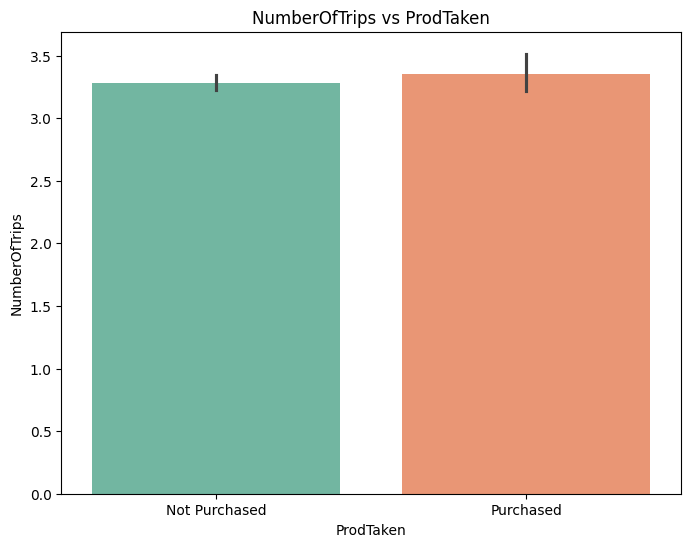

In [42]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df2, x='ProdTaken', y='NumberOfTrips', palette='Set2')
plt.title('NumberOfTrips vs ProdTaken')
plt.xlabel('ProdTaken')
plt.ylabel('NumberOfTrips')
plt.xticks([0, 1], ['Not Purchased', 'Purchased'])
plt.show()

/tmp/ipykernel_2276/1131960082.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='ProdTaken', y='NumberOfTrips', palette='Set2')


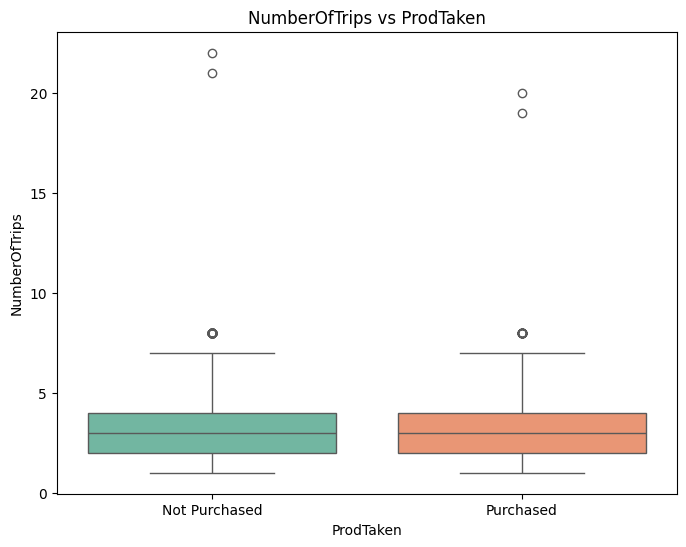

In [43]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df2, x='ProdTaken', y='NumberOfTrips', palette='Set2')
plt.title('NumberOfTrips vs ProdTaken')
plt.xlabel('ProdTaken')
plt.ylabel('NumberOfTrips')
plt.xticks([0, 1], ['Not Purchased', 'Purchased'])
plt.show()

#### 6.3.1.8. <a id='toc6_3_1_8_'></a>[ProdTaken vs Passport](#toc0_)

/tmp/ipykernel_2276/4229719445.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=passport_rate.index, y=passport_rate.values, palette="Set2")


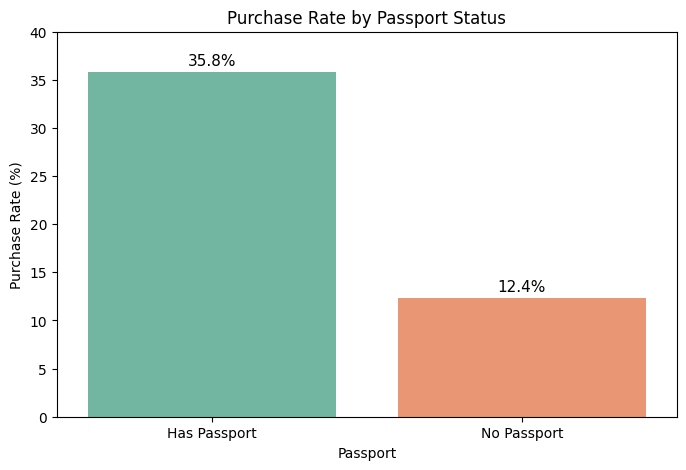

In [44]:
df2['PassportLabel'] = df2['Passport'].map({0: 'No Passport', 1: 'Has Passport'})

passport_rate = df2.groupby('PassportLabel')['ProdTaken'].mean().mul(100)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=passport_rate.index, y=passport_rate.values, palette="Set2")

plt.title("Purchase Rate by Passport Status")
plt.xlabel("Passport")
plt.ylabel("Purchase Rate (%)")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=11
    )

plt.ylim(0, 40)
plt.show()

#### 6.3.1.9. <a id='toc6_3_1_9_'></a>[ProdTaken vs PitchSatisfactionScore](#toc0_)

/tmp/ipykernel_2276/2406627785.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=pitch_sat_rate.index, y=pitch_sat_rate.values, palette='Blues')


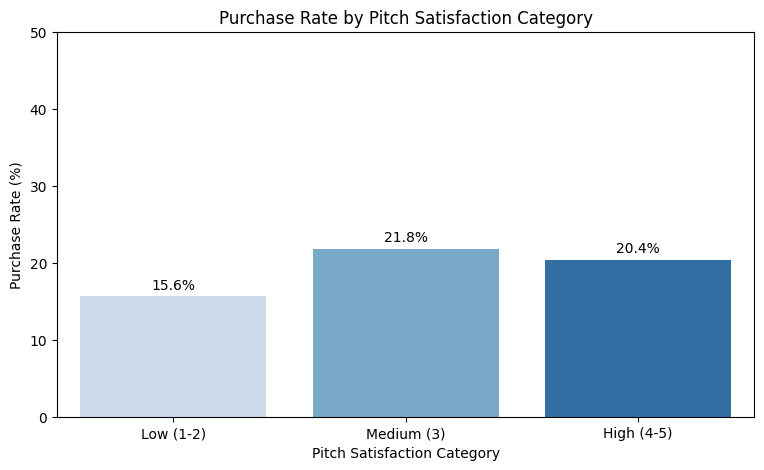

In [45]:
# Create categories for PitchSatisfactionScore
bins = [0, 2, 3, 5]
labels = ['Low (1-2)', 'Medium (3)', 'High (4-5)']
df2['PitchSatisfactionBand'] = pd.cut(
    df2['PitchSatisfactionScore'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Purchase rate by pitch satisfaction category
pitch_sat_rate = df2.groupby('PitchSatisfactionBand', observed=False)['ProdTaken'].mean().mul(100)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=pitch_sat_rate.index, y=pitch_sat_rate.values, palette='Blues')

plt.title('Purchase Rate by Pitch Satisfaction Category')
plt.xlabel('Pitch Satisfaction Category')
plt.ylabel('Purchase Rate (%)')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=10
    )

plt.ylim(0, 50)
plt.show()

/tmp/ipykernel_2276/4153205793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df2, x='ProdTaken', y='PitchSatisfactionScore', palette='Set2')


/tmp/ipykernel_2276/4153205793.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Purchased', 'Purchased'])


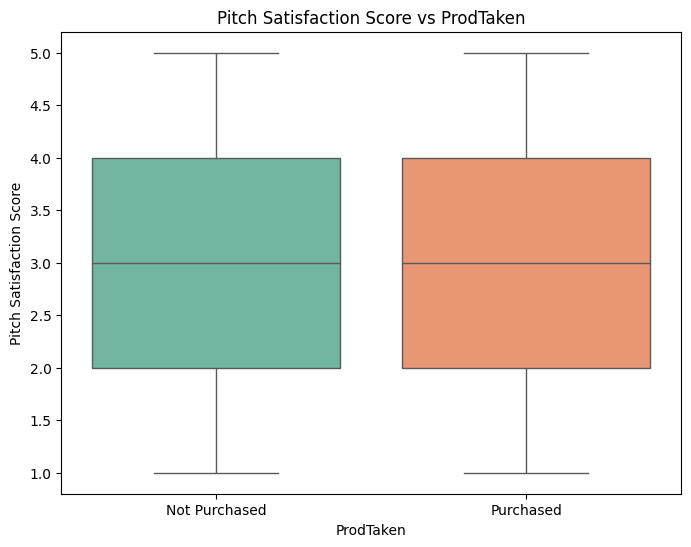

In [46]:
plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=df2, x='ProdTaken', y='PitchSatisfactionScore', palette='Set2')
plt.title('Pitch Satisfaction Score vs ProdTaken')
plt.xlabel('ProdTaken')
plt.ylabel('Pitch Satisfaction Score')
ax.set_xticklabels(['Not Purchased', 'Purchased'])
plt.show()

In [47]:
numeric_data.dtypes

Age                         float64
CityTier                    float64
NumberOfPersonVisiting      float64
PreferredPropertyStar       float64
NumberOfTrips               float64
Passport                    float64
OwnCar                      float64
NumberOfChildrenVisiting    float64
MonthlyIncome               float64
DurationOfPitch             float64
NumberOfFollowups           float64
PitchSatisfactionScore      float64
ProdTaken                     int64
dtype: object

#### 6.3.1.10. <a id='toc6_3_1_10_'></a>[ProdTaken vs OwnCar](#toc0_)

/tmp/ipykernel_2276/2713363959.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=own_car_rate.index, y=own_car_rate.values, palette='Set2')


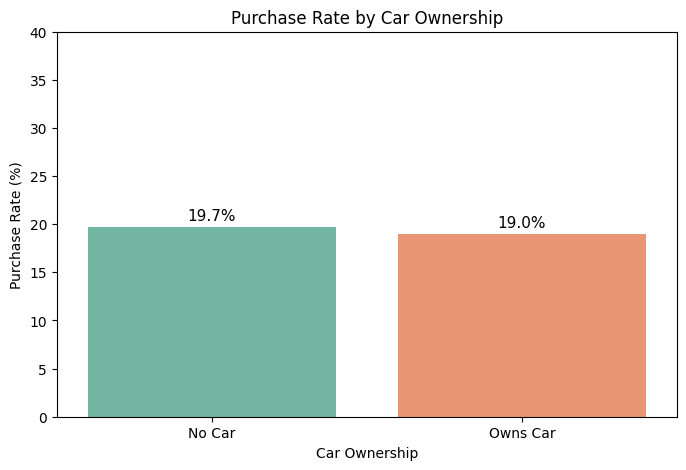

/tmp/ipykernel_2276/2713363959.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df2, x='ProdTaken', y='OwnCar', palette='Set2')
/tmp/ipykernel_2276/2713363959.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Purchased', 'Purchased'])


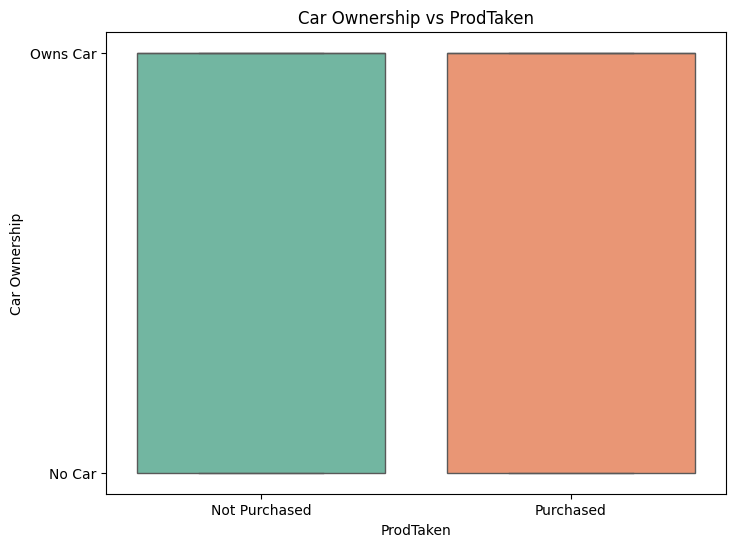

In [48]:
# Categorise OwnCar
own_car_labels = {0: 'No Car', 1: 'Owns Car'}
df2['OwnCarCategory'] = df2['OwnCar'].map(own_car_labels)

# Purchase rate by OwnCar category
own_car_rate = df2.groupby('OwnCarCategory', observed=False)['ProdTaken'].mean().mul(100)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=own_car_rate.index, y=own_car_rate.values, palette='Set2')

plt.title('Purchase Rate by Car Ownership')
plt.xlabel('Car Ownership')
plt.ylabel('Purchase Rate (%)')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=11
    )

plt.ylim(0, 40)
plt.show()

# Distribution of car ownership by purchase outcome
plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=df2, x='ProdTaken', y='OwnCar', palette='Set2')
plt.title('Car Ownership vs ProdTaken')
plt.xlabel('ProdTaken')
plt.ylabel('Car Ownership')
ax.set_xticklabels(['Not Purchased', 'Purchased'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['No Car', 'Owns Car'])
plt.show()

#### 6.3.1.11. <a id='toc6_3_1_11_'></a>[ProdTaken vs NumberOfChildrenVisiting](#toc0_)

/tmp/ipykernel_2276/3071534477.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


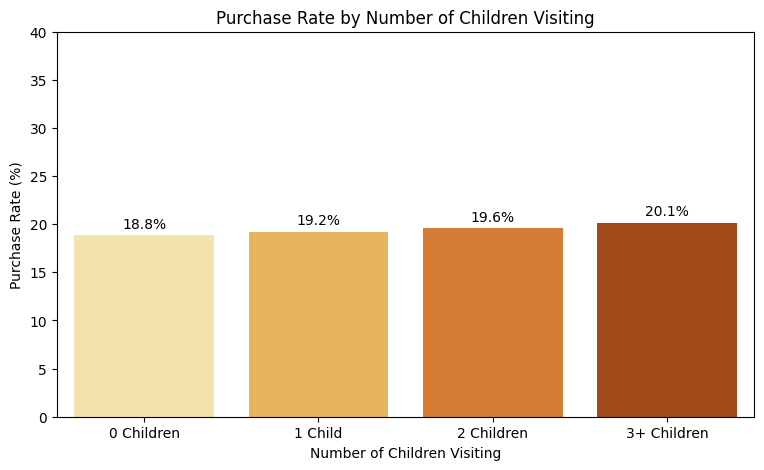

/tmp/ipykernel_2276/3071534477.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_2276/3071534477.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Purchased', 'Purchased'])


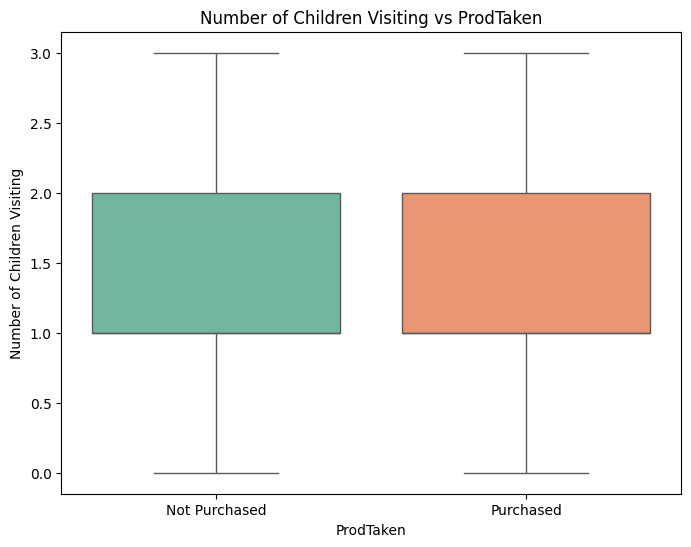

In [49]:
# Categorise NumberOfChildrenVisiting
bins = [-1, 0, 1, 2, np.inf]
labels = ['0 Children', '1 Child', '2 Children', '3+ Children']
df2['ChildrenVisitingCategory'] = pd.cut(
    df2['NumberOfChildrenVisiting'],
    bins=bins,
    labels=labels
)

# Purchase rate by number of children visiting
children_visit_rate = df2.groupby(
    'ChildrenVisitingCategory', observed=False
)['ProdTaken'].mean().mul(100)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=children_visit_rate.index,
    y=children_visit_rate.values,
    palette='YlOrBr'
)

plt.title('Purchase Rate by Number of Children Visiting')
plt.xlabel('Number of Children Visiting')
plt.ylabel('Purchase Rate (%)')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=10
    )

plt.ylim(0, 40)
plt.show()

# Distribution of children visiting by purchase outcome
plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    data=df2,
    x='ProdTaken',
    y='NumberOfChildrenVisiting',
    palette='Set2'
)
plt.title('Number of Children Visiting vs ProdTaken')
plt.xlabel('ProdTaken')
plt.ylabel('Number of Children Visiting')
ax.set_xticklabels(['Not Purchased', 'Purchased'])
plt.show()

#### 6.3.1.12. <a id='toc6_3_1_12_'></a>[ProdTaken vs MonthlyIncome](#toc0_)

/tmp/ipykernel_2276/3419892509.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


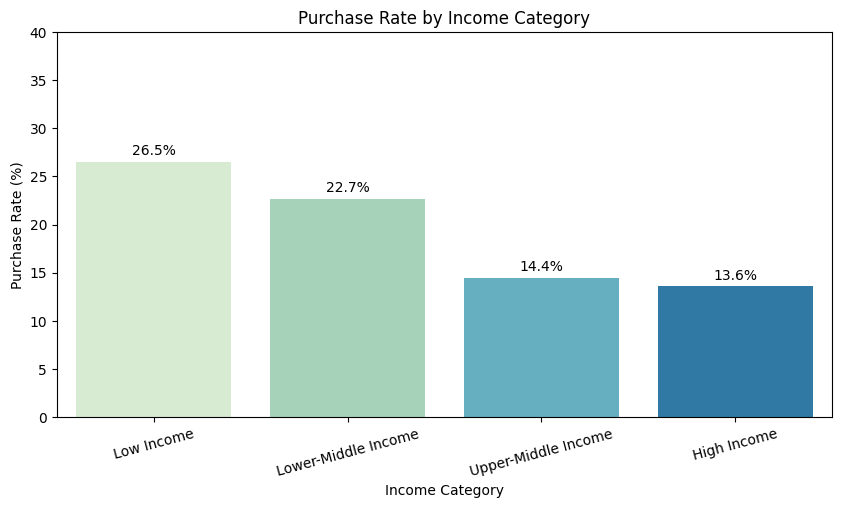

/tmp/ipykernel_2276/3419892509.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


/tmp/ipykernel_2276/3419892509.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Purchased', 'Purchased'])


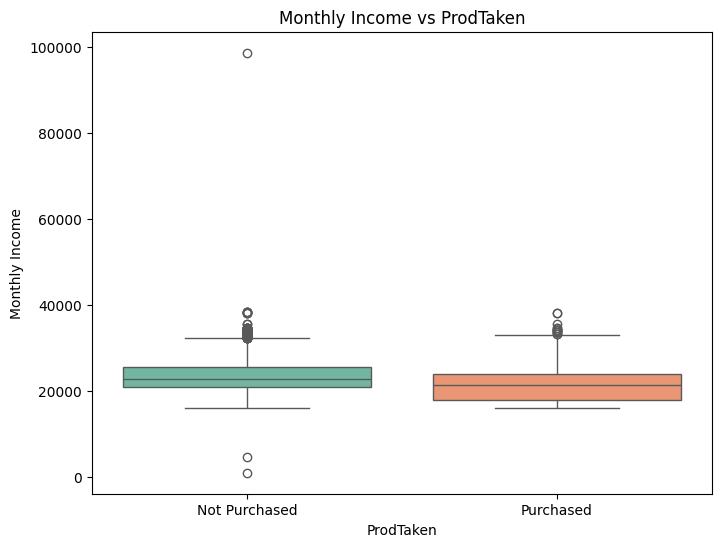

In [50]:
# Categorise MonthlyIncome into quartile-based income bands
income_labels = ['Low Income', 'Lower-Middle Income', 'Upper-Middle Income', 'High Income']
df2['IncomeCategory'] = pd.qcut(
    df2['MonthlyIncome'],
    q=4,
    labels=income_labels
)

# Purchase rate by income category
income_purchase_rate = df2.groupby(
    'IncomeCategory', observed=False
)['ProdTaken'].mean().mul(100)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=income_purchase_rate.index,
    y=income_purchase_rate.values,
    palette='GnBu'
)

plt.title('Purchase Rate by Income Category')
plt.xlabel('Income Category')
plt.ylabel('Purchase Rate (%)')
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=10
    )

plt.ylim(0, 40)
plt.show()

# Distribution of MonthlyIncome by purchase outcome
plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    data=df2,
    x='ProdTaken',
    y='MonthlyIncome',
    palette='Set2'
)
plt.title('Monthly Income vs ProdTaken')
plt.xlabel('ProdTaken')
plt.ylabel('Monthly Income')
ax.set_xticklabels(['Not Purchased', 'Purchased'])
plt.show()

## 6.4. <a id='toc6_4_'></a>[Multivariate Analysis - Non-numeric variables](#toc0_)

In [51]:
objects_data.dtypes

Occupation        object
Gender            object
MaritalStatus     object
Designation       object
TypeofContact     object
ProductPitched    object
dtype: object

### 6.4.1. <a id='toc6_4_1_'></a>[ProdTaken vs TypeofContact](#toc0_)

/tmp/ipykernel_2276/3744127901.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


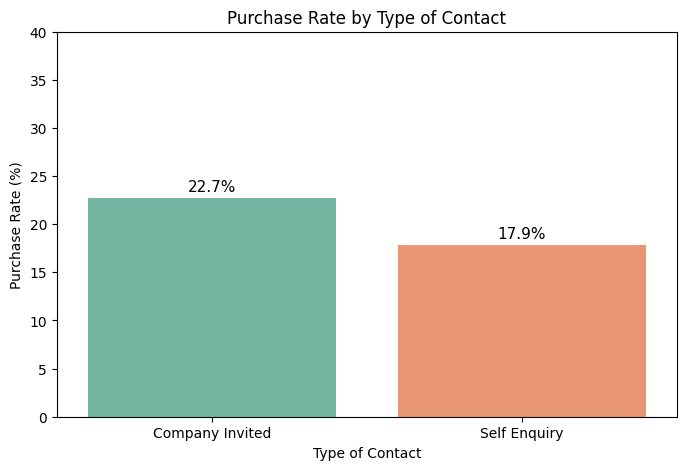

In [52]:
# Purchase rate by TypeofContact
contact_purchase_rate = df2.groupby('TypeofContact')['ProdTaken'].mean().mul(100)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=contact_purchase_rate.index,
    y=contact_purchase_rate.values,
    palette='Set2'
)

plt.title('Purchase Rate by Type of Contact')
plt.xlabel('Type of Contact')
plt.ylabel('Purchase Rate (%)')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=11
    )

plt.ylim(0, 40)
plt.show()

### 6.4.2. <a id='toc6_4_2_'></a>[ProdTaken vs Occupation](#toc0_)

/tmp/ipykernel_2276/1287150191.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


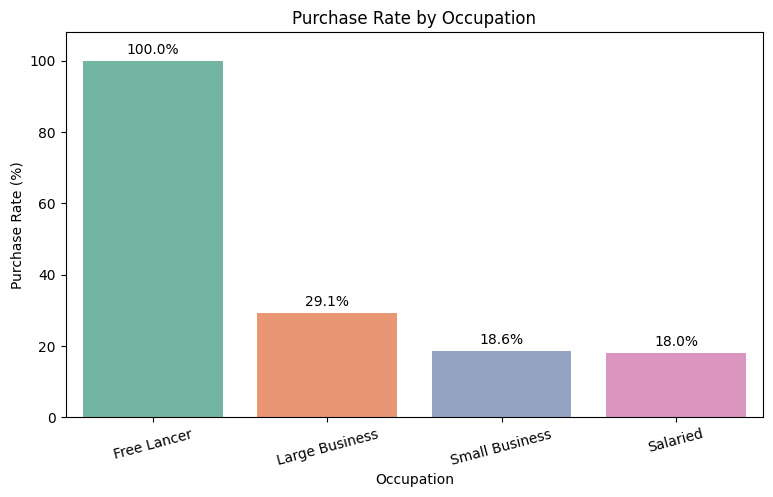

In [53]:
# Purchase rate by Occupation
occupation_purchase_rate = df2.groupby('Occupation')['ProdTaken'].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=occupation_purchase_rate.index,
    y=occupation_purchase_rate.values,
    palette='Set2'
)

plt.title('Purchase Rate by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Purchase Rate (%)')
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=10
    )

plt.ylim(0, occupation_purchase_rate.max() + 8)
plt.show()

### 6.4.3. <a id='toc6_4_3_'></a>[ProdTaken vs Gender](#toc0_)

/tmp/ipykernel_2276/38514139.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


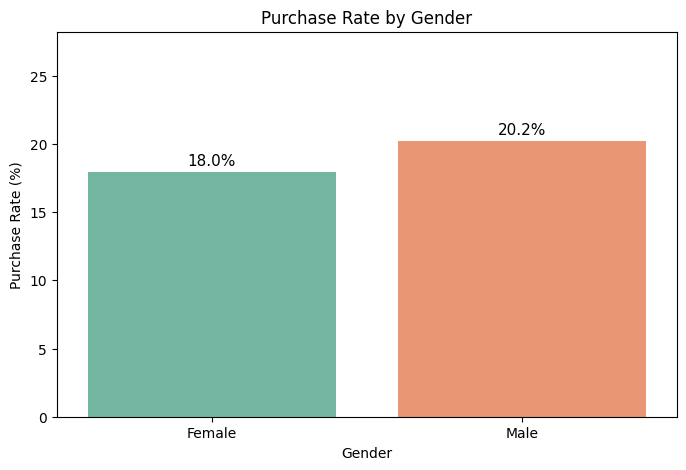

In [54]:
# Purchase rate by Gender
gender_purchase_rate = df2.groupby('Gender')['ProdTaken'].mean().mul(100)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=gender_purchase_rate.index,
    y=gender_purchase_rate.values,
    palette='Set2'
)

plt.title('Purchase Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Purchase Rate (%)')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=11
    )

plt.ylim(0, gender_purchase_rate.max() + 8)
plt.show()

### 6.4.4. <a id='toc6_4_4_'></a>[ProdTaken vs ProductPitched](#toc0_)

/tmp/ipykernel_2276/3523153662.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


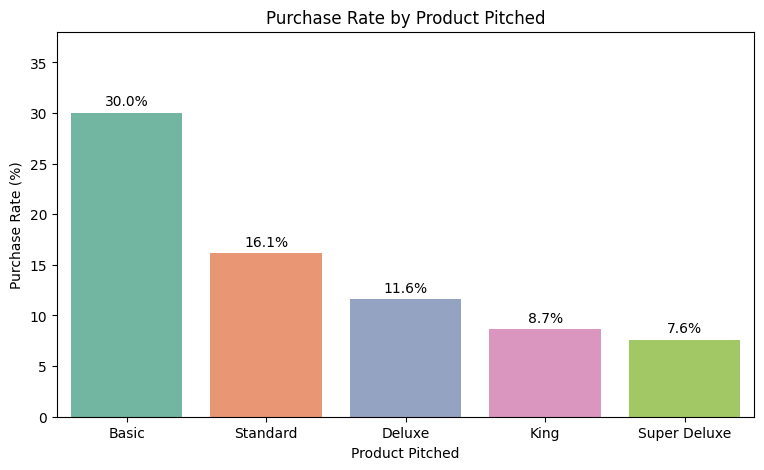

In [55]:
# Purchase rate by ProductPitched
product_purchase_rate = df2.groupby('ProductPitched')['ProdTaken'].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=product_purchase_rate.index,
    y=product_purchase_rate.values,
    palette='Set2'
)

plt.title('Purchase Rate by Product Pitched')
plt.xlabel('Product Pitched')
plt.ylabel('Purchase Rate (%)')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=10
    )

plt.ylim(0, product_purchase_rate.max() + 8)
plt.show()

### 6.4.5. <a id='toc6_4_5_'></a>[ProdTaken vs MaritalStatus](#toc0_)

/tmp/ipykernel_2276/2797584548.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


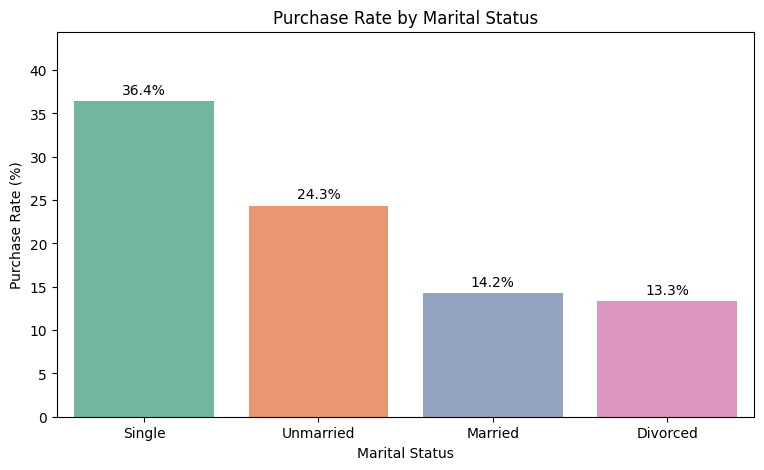

In [56]:
# Purchase rate by MaritalStatus
marital_purchase_rate = df2.groupby('MaritalStatus')['ProdTaken'].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=marital_purchase_rate.index,
    y=marital_purchase_rate.values,
    palette='Set2'
)

plt.title('Purchase Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Purchase Rate (%)')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=10
    )

plt.ylim(0, marital_purchase_rate.max() + 8)
plt.show()

### 6.4.6. <a id='toc6_4_6_'></a>[ProdTaken vs Designation](#toc0_)

/tmp/ipykernel_2276/1242223265.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


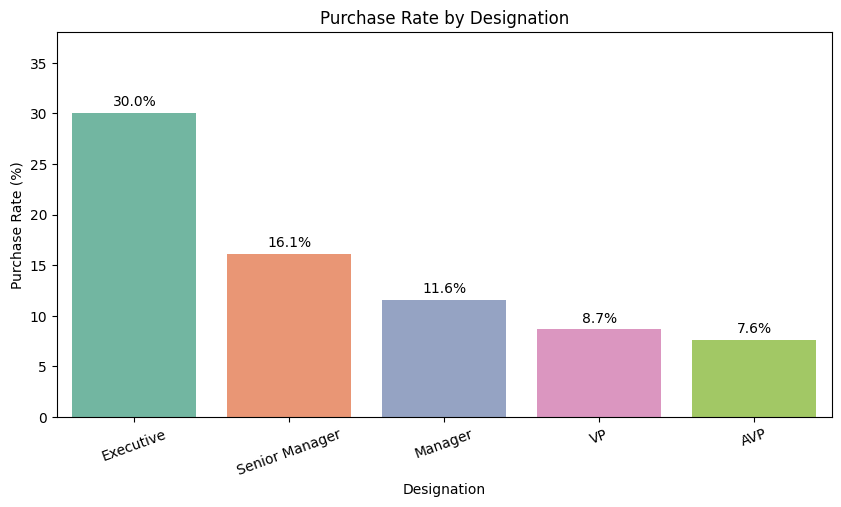

In [57]:
# Purchase rate by Designation
designation_purchase_rate = df2.groupby('Designation')['ProdTaken'].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=designation_purchase_rate.index,
    y=designation_purchase_rate.values,
    palette='Set2'
)

plt.title('Purchase Rate by Designation')
plt.xlabel('Designation')
plt.ylabel('Purchase Rate (%)')
plt.xticks(rotation=20)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=10
    )

plt.ylim(0, designation_purchase_rate.max() + 8)
plt.show()

#### 6.4.6.1. <a id='toc6_4_6_1_'></a>[Correlation matrix](#toc0_)

##### 6.4.6.1.1. <a id='toc6_4_6_1_1_'></a>[Continous & Discreet Variables](#toc0_)

In [58]:
numeric_data

,Age,CityTier,NumberOfPersonVisiting,PreferredPropertyStar,NumberOfTrips,Passport,OwnCar,NumberOfChildrenVisiting,MonthlyIncome,DurationOfPitch,NumberOfFollowups,PitchSatisfactionScore,ProdTaken
0,41.0,3.0,3.0,3.0,1.0,1.0,1.0,0.0,20993.0,6.0,3.0,2.0,1
1,49.0,1.0,3.0,4.0,2.0,0.0,1.0,2.0,20130.0,14.0,4.0,3.0,0
2,37.0,1.0,3.0,3.0,7.0,1.0,0.0,0.0,17090.0,8.0,4.0,3.0,1
3,33.0,1.0,2.0,3.0,2.0,1.0,1.0,1.0,17909.0,9.0,3.0,5.0,0
4,32.0,1.0,3.0,3.0,1.0,0.0,1.0,1.0,18068.0,8.0,3.0,5.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4123,49.0,3.0,3.0,4.0,2.0,1.0,1.0,1.0,26576.0,9.0,5.0,1.0,1
4124,28.0,1.0,4.0,3.0,3.0,1.0,1.0,2.0,21212.0,31.0,5.0,3.0,1
4125,52.0,3.0,4.0,4.0,7.0,0.0,1.0,3.0,31820.0,17.0,4.0,1.0,1
4126,19.0,3.0,3.0,3.0,3.0,0.0,0.0,2.0,20289.0,16.0,4.0,5.0,1


In [59]:
numeric_data.columns

Index(['Age', 'CityTier', 'NumberOfPersonVisiting', 'PreferredPropertyStar',
       'NumberOfTrips', 'Passport', 'OwnCar', 'NumberOfChildrenVisiting',
       'MonthlyIncome', 'DurationOfPitch', 'NumberOfFollowups',
       'PitchSatisfactionScore', 'ProdTaken'],
      dtype='object')

In [60]:
columns_to_drop = ['ProdTaken', 'CityTier', 'PreferredPropertyStar', 
                                'Passport', 'PitchSatisfactionScore', 'OwnCar']

numeric_data_cleaned = numeric_data.drop(columns=columns_to_drop)
numeric_data_cleaned

,Age,NumberOfPersonVisiting,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome,DurationOfPitch,NumberOfFollowups
0,41.0,3.0,1.0,0.0,20993.0,6.0,3.0
1,49.0,3.0,2.0,2.0,20130.0,14.0,4.0
2,37.0,3.0,7.0,0.0,17090.0,8.0,4.0
3,33.0,2.0,2.0,1.0,17909.0,9.0,3.0
4,32.0,3.0,1.0,1.0,18068.0,8.0,3.0
...,...,...,...,...,...,...,...
4123,49.0,3.0,2.0,1.0,26576.0,9.0,5.0
4124,28.0,4.0,3.0,2.0,21212.0,31.0,5.0
4125,52.0,4.0,7.0,3.0,31820.0,17.0,4.0
4126,19.0,3.0,3.0,2.0,20289.0,16.0,4.0


In [61]:
# Pearson correlation matrix

from typing import Literal

def plot_correlation_matrix(data, figsize=(12, 8), annot=True, cmap="coolwarm", title="Correlation Matrix", method:Literal["pearson", "kendall", "spearman"]="pearson"):
    """Plot a correlation matrix for numeric columns."""
    numeric_data = data.select_dtypes(include=np.number)
    correlation_matrix = numeric_data.corr(method=method)

    plt.figure(figsize=figsize)
    sns.heatmap(
        correlation_matrix,
        annot=annot,
        fmt=".2f",
        cmap=cmap,
        center=0,
        square=True,
        linewidths=0.5
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

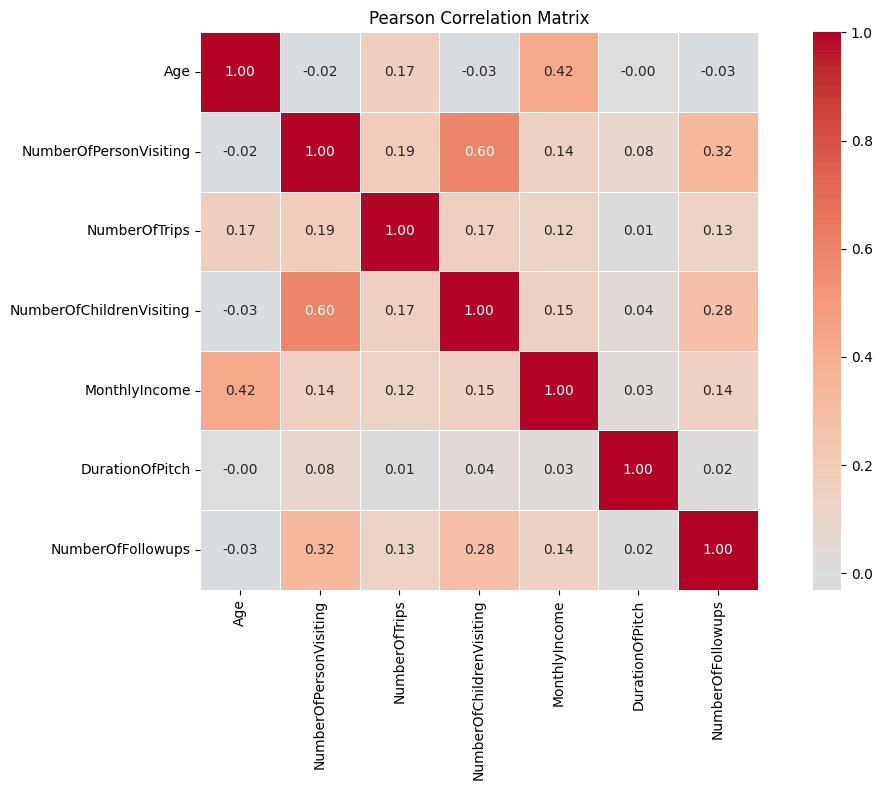

In [62]:
# Pearson correlation matrix
plot_correlation_matrix(numeric_data_cleaned, title="Pearson Correlation Matrix")

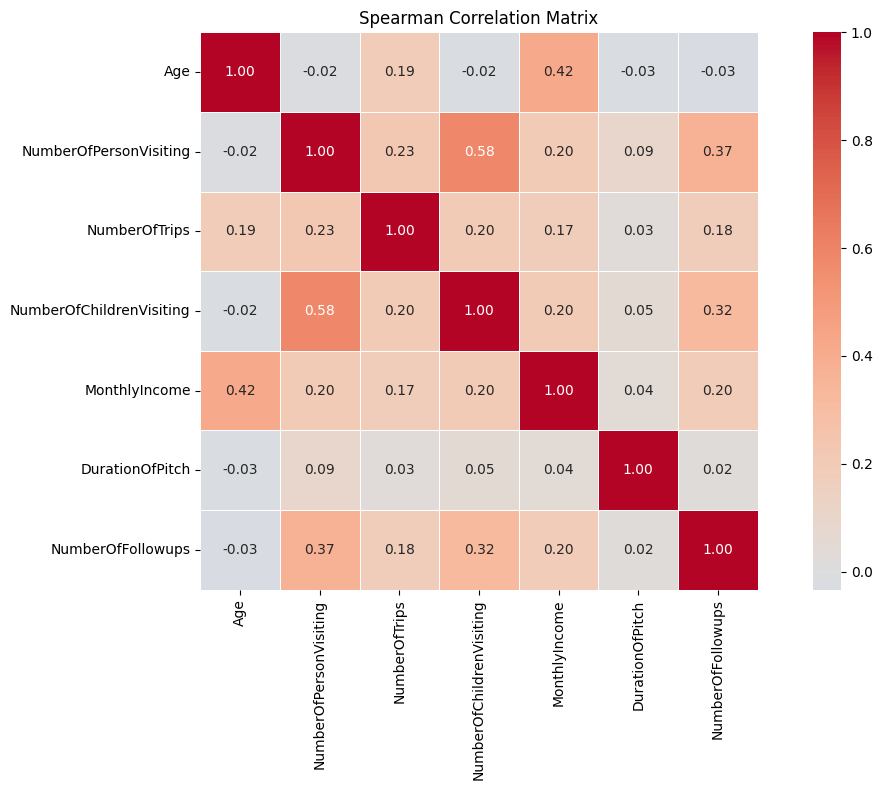

In [63]:
# Spearman correlation matrix
plot_correlation_matrix(numeric_data_cleaned, method="spearman", title="Spearman Correlation Matrix")

In [64]:
# Measuring multicollinearity among numeric predictor variables  using VIF  - (Variance Inflation Factor)

# A VIF value greater than 10 indicates high multicollinearity, which may require further investigation or remedial measures
# VIF close to 1 indicates little or no multicollinearity.
# VIF values between 1 and 5 are generally acceptable.
# VIF values above 5 indicate possible multicollinearity,
# VIF values above 10 indicate serious multicollinearity.

# Calculate Variance Inflation Factors (VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(data, target=None):
    """Calculate VIF for numeric predictor variables."""
    numeric_data = data.select_dtypes(include=np.number).copy()

    if target and target in numeric_data.columns:
        numeric_data = numeric_data.drop(columns=[target])

    numeric_data = numeric_data.replace([np.inf, -np.inf], np.nan).dropna()
    numeric_data = add_constant(numeric_data)

    vif_data = pd.DataFrame({
        "Feature": numeric_data.columns,
        "VIF": [
            variance_inflation_factor(numeric_data.values, i)
            for i in range(numeric_data.shape[1])
        ]
    })

    return vif_data[vif_data["Feature"] != "const"].sort_values(
        by="VIF", ascending=False
    )

# Calculate VIF
vif_results = calculate_vif(numeric_data_cleaned)
vif_results

,Feature,VIF
2,NumberOfPersonVisiting,1.647505
4,NumberOfChildrenVisiting,1.595718
5,MonthlyIncome,1.276242
1,Age,1.268443
7,NumberOfFollowups,1.153745
3,NumberOfTrips,1.083278
6,DurationOfPitch,1.006450


Observations

 - All VIF are low between (1 - 1.6), indicating that there is no significant multicolinearlity

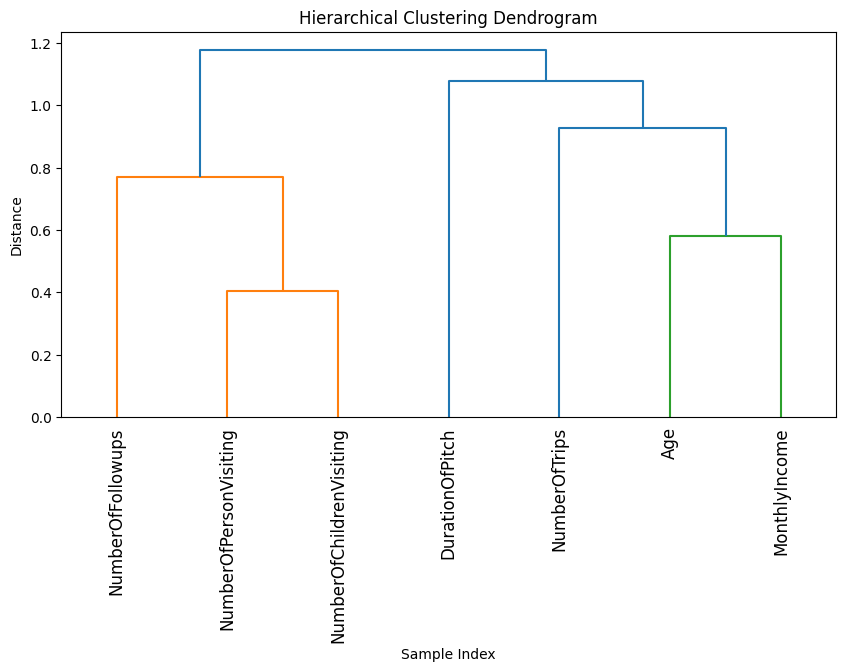

In [65]:
# Hierarchical Clustering Dendrogram
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Get column names of numeric_data_cleaned
numeric_columns = numeric_data_cleaned.columns

# Calculate the correlation matrix
correlation_matrix = numeric_data_cleaned.corr()

# Convert to a distance matrix
distance_matrix = 1 - np.abs(correlation_matrix)
distance_matrix = squareform(distance_matrix)

# 1. Compute the linkage matrix (uses Ward's method by default to minimize variance)
# Other popular methods include 'single', 'complete', or 'average'
linkage_matrix = linkage(distance_matrix, method='ward')

# 2. Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, labels=numeric_columns)

# 3. Customize and display the plot
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.xticks(rotation=90)
plt.show()


##### 6.4.6.1.2. <a id='toc6_4_6_1_2_'></a>[Categorical Variables](#toc0_)

In [66]:
columns_to_drop = ['Age', 'DurationOfPitch', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'NumberOfTrips', 'NumberOfChildrenVisiting', 'MonthlyIncome']
cat_data_cleaned = df2.drop(columns=columns_to_drop)
cat_data_cleaned

,CityTier,Occupation,Gender,PreferredPropertyStar,MaritalStatus,Passport,OwnCar,Designation,TypeofContact,ProductPitched,PitchSatisfactionScore,ProdTaken,AgeGroup,PassportLabel,PitchSatisfactionBand,OwnCarCategory,ChildrenVisitingCategory,IncomeCategory
0,3.0,Salaried,Female,3.0,Single,1.0,1.0,Manager,Self Enquiry,Deluxe,2.0,1,41-50,Has Passport,Low (1-2),Owns Car,0 Children,Lower-Middle Income
1,1.0,Salaried,Male,4.0,Divorced,0.0,1.0,Manager,Company Invited,Deluxe,3.0,0,41-50,No Passport,Medium (3),Owns Car,2 Children,Low Income
2,1.0,Free Lancer,Male,3.0,Single,1.0,0.0,Executive,Self Enquiry,Basic,3.0,1,31-40,Has Passport,Medium (3),No Car,0 Children,Low Income
3,1.0,Salaried,Female,3.0,Divorced,1.0,1.0,Executive,Company Invited,Basic,5.0,0,31-40,Has Passport,High (4-5),Owns Car,1 Child,Low Income
4,1.0,Salaried,Male,3.0,Single,0.0,1.0,Executive,Company Invited,Basic,5.0,0,31-40,No Passport,High (4-5),Owns Car,1 Child,Low Income
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4123,3.0,Small Business,Male,4.0,Unmarried,1.0,1.0,Manager,Self Enquiry,Deluxe,1.0,1,41-50,Has Passport,Low (1-2),Owns Car,1 Child,High Income
4124,1.0,Salaried,Male,3.0,Single,1.0,1.0,Executive,Company Invited,Basic,3.0,1,21-30,Has Passport,Medium (3),Owns Car,2 Children,Lower-Middle Income
4125,3.0,Salaried,Female,4.0,Married,0.0,1.0,Senior Manager,Self Enquiry,Standard,1.0,1,51-60,No Passport,Low (1-2),Owns Car,3+ Children,High Income
4126,3.0,Small Business,Male,3.0,Single,0.0,0.0,Executive,Self Enquiry,Basic,5.0,1,<=20,No Passport,High (4-5),No Car,2 Children,Low Income


Chi-Square test

In [67]:
from itertools import product
import numpy as np
import scipy.stats as ss

In [68]:
cat_data_cleaned.columns

Index(['CityTier', 'Occupation', 'Gender', 'PreferredPropertyStar',
       'MaritalStatus', 'Passport', 'OwnCar', 'Designation', 'TypeofContact',
       'ProductPitched', 'PitchSatisfactionScore', 'ProdTaken', 'AgeGroup',
       'PassportLabel', 'PitchSatisfactionBand', 'OwnCarCategory',
       'ChildrenVisitingCategory', 'IncomeCategory'],
      dtype='object')

In [69]:
# Let us split this list into two parts
cat_var1 = ('ProdTaken', 'TypeofContact', 'CityTier', 'Occupation', 'Gender',
       'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'Designation')

cat_var2 = ('ProdTaken', 'TypeofContact', 'CityTier', 'Occupation', 'Gender',
       'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'Designation')

In [70]:
## Creating all possible combinations between the above two variables list
cat_var_prod = list(product(cat_var1,cat_var2, repeat = 1))
cat_var_prod

[('ProdTaken', 'ProdTaken'),
 ('ProdTaken', 'TypeofContact'),
 ('ProdTaken', 'CityTier'),
 ('ProdTaken', 'Occupation'),
 ('ProdTaken', 'Gender'),
 ('ProdTaken', 'ProductPitched'),
 ('ProdTaken', 'PreferredPropertyStar'),
 ('ProdTaken', 'MaritalStatus'),
 ('ProdTaken', 'Passport'),
 ('ProdTaken', 'PitchSatisfactionScore'),
 ('ProdTaken', 'OwnCar'),
 ('ProdTaken', 'Designation'),
 ('TypeofContact', 'ProdTaken'),
 ('TypeofContact', 'TypeofContact'),
 ('TypeofContact', 'CityTier'),
 ('TypeofContact', 'Occupation'),
 ('TypeofContact', 'Gender'),
 ('TypeofContact', 'ProductPitched'),
 ('TypeofContact', 'PreferredPropertyStar'),
 ('TypeofContact', 'MaritalStatus'),
 ('TypeofContact', 'Passport'),
 ('TypeofContact', 'PitchSatisfactionScore'),
 ('TypeofContact', 'OwnCar'),
 ('TypeofContact', 'Designation'),
 ('CityTier', 'ProdTaken'),
 ('CityTier', 'TypeofContact'),
 ('CityTier', 'CityTier'),
 ('CityTier', 'Occupation'),
 ('CityTier', 'Gender'),
 ('CityTier', 'ProductPitched'),
 ('CityTier', 'P

In [71]:
## Creating an empty variable and picking only the p value from the output of Chi-Square test
result = []
for i in cat_var_prod:
    if i[0] != i[1]:
        result.append((i[0],i[1],list(ss.chi2_contingency(pd.crosstab(cat_data_cleaned[i[0]], 
                                                                        cat_data_cleaned[i[1]])))[1]))
                                                                        
result

[('ProdTaken', 'TypeofContact', np.float64(0.0003976652145041528)),
 ('ProdTaken', 'CityTier', np.float64(5.765302256699178e-09)),
 ('ProdTaken', 'Occupation', np.float64(1.3140225743955844e-07)),
 ('ProdTaken', 'Gender', np.float64(0.0774762572575442)),
 ('ProdTaken', 'ProductPitched', np.float64(8.401617515724734e-44)),
 ('ProdTaken', 'PreferredPropertyStar', np.float64(5.979791295547132e-10)),
 ('ProdTaken', 'MaritalStatus', np.float64(1.7291586413197554e-40)),
 ('ProdTaken', 'Passport', np.float64(1.0313677084387544e-67)),
 ('ProdTaken', 'PitchSatisfactionScore', np.float64(0.0004851102916430564)),
 ('ProdTaken', 'OwnCar', np.float64(0.6049445767143257)),
 ('ProdTaken', 'Designation', np.float64(8.401617515724734e-44)),
 ('TypeofContact', 'ProdTaken', np.float64(0.00039766521450415343)),
 ('TypeofContact', 'CityTier', np.float64(0.2653697034952413)),
 ('TypeofContact', 'Occupation', np.float64(0.028657635741859696)),
 ('TypeofContact', 'Gender', np.float64(0.7037885814127708)),
 ('

In [72]:
chi_test_output = pd.DataFrame(result, columns = ['var1', 'var2', 'coeff'])

## Using pivot function to convert the above DataFrame into a crosstab
chi_test_output_pivot_table = chi_test_output.pivot(index='var1', columns='var2', values='coeff')
chi_test_output_pivot_table

var2,CityTier,Designation,Gender,MaritalStatus,Occupation,OwnCar,Passport,PitchSatisfactionScore,PreferredPropertyStar,ProdTaken,ProductPitched,TypeofContact
var1,,,,,,,,,,,,
CityTier,NaN,4.224703e-76,0.038652,9.055462e-10,4.623291e-31,0.688603,8.300783e-01,2.253918e-02,1.221234e-02,5.765302e-09,4.224703e-76,0.265370
Designation,4.224703e-76,NaN,0.004676,3.590139e-66,7.320858e-04,0.000098,3.563605e-01,1.062550e-06,3.667377e-02,8.401618e-44,0.000000e+00,0.180669
Gender,3.865197e-02,4.676308e-03,NaN,1.605027e-02,6.593165e-01,0.353402,7.247607e-02,1.428582e-01,6.687877e-02,7.747626e-02,4.676308e-03,0.703789
MaritalStatus,9.055462e-10,3.590139e-66,0.016050,NaN,9.119367e-02,0.217966,1.400874e-01,5.240480e-79,2.272649e-01,1.729159e-40,3.590139e-66,0.163702
Occupation,4.623291e-31,7.320858e-04,0.659317,9.119367e-02,NaN,0.013071,1.591732e-01,1.037479e-03,1.061323e-01,1.314023e-07,7.320858e-04,0.028658
OwnCar,6.886028e-01,9.786705e-05,0.353402,2.179656e-01,1.307094e-02,NaN,8.340869e-02,1.260173e-04,5.166277e-01,6.049446e-01,9.786705e-05,0.876499
Passport,8.300783e-01,3.563605e-01,0.072476,1.400874e-01,1.591732e-01,0.083409,NaN,6.502908e-01,7.436539e-02,1.031368e-67,3.563605e-01,0.988845
PitchSatisfactionScore,2.253918e-02,1.062550e-06,0.142858,5.240480e-79,1.037479e-03,0.000126,6.502908e-01,NaN,2.487821e-03,4.851103e-04,1.062550e-06,0.001637
PreferredPropertyStar,1.221234e-02,3.667377e-02,0.066879,2.272649e-01,1.061323e-01,0.516628,7.436539e-02,2.487821e-03,NaN,5.979791e-10,3.667377e-02,0.112547


# 7. <a id='toc7_'></a>[Feature Engineering](#toc0_)

## 7.1. <a id='toc7_1_'></a>[Encoding categorical variables](#toc0_)

In [73]:
# Raw input contracts exclude IDs, the target, and all EDA-only columns.
feature_contract = pd.DataFrame({
    'Feature': FEATURES['post_interaction'],
    'Available before contact': [field in FEATURES['pre_contact'] for field in FEATURES['post_interaction']],
    'Encoding': ['One-hot' if field in CATEGORICAL else 'Numeric/ordinal' for field in FEATURES['post_interaction']],
})
display(feature_contract)

# This unfitted blueprint is cloned inside each CV fold by the training module.
# Median/mode imputation and one-hot categories never learn from validation/test data.
pipeline_blueprint = build_pipeline('pre_contact', RandomForestClassifier(random_state=config['seed']))
pipeline_blueprint

,Feature,Available before contact,Encoding
0,Age,True,Numeric/ordinal
1,CityTier,True,One-hot
2,Occupation,True,One-hot
3,Gender,True,One-hot
4,NumberOfPersonVisiting,True,Numeric/ordinal
5,PreferredPropertyStar,True,Numeric/ordinal
6,MaritalStatus,True,One-hot
7,NumberOfTrips,True,Numeric/ordinal
8,Passport,True,Numeric/ordinal
9,OwnCar,True,Numeric/ordinal


Pipeline(steps=[('select', FeatureSelector()),
                ('preprocess',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(keep_empty_features=True,
                                                                                 strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['CityTier', 'Occupation',
                                                   'Gender', 'MaritalStatus',
                                                   'Designation']),
                                                 ('numeric',
                                                  SimpleImputer(keep_empty_features=True,
                                                                strategy='median'),
                                                  ['Age',
                                                   'NumberOfPersonVisiting',
                                                   'PreferredPropertyStar',
                                                   'NumberOfTrips', 'Passport',
                                                   'OwnCar',
                                                   'NumberOfChildrenVisiting',
                                                   'MonthlyIncome'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [74]:
# Plot-only categories are deliberately absent from both production contracts.
eda_only = {'AgeGroup', 'IncomeCategory', 'PassportLabel', 'OwnCarCategory', 'PitchSatisfactionBand', 'ChildrenVisitingCategory'}
assert not eda_only.intersection(FEATURES['post_interaction'])
print('Pre-contact features:', len(FEATURES['pre_contact']))
print('Post-interaction features:', len(FEATURES['post_interaction']))

Pre-contact features: 13
Post-interaction features: 18


# 8. <a id='toc8_'></a>[Data splitting](#toc0_)

## 8.1. <a id='toc8_1_'></a>[Splitting data into Training, Validation and Test sets](#toc0_)

In [75]:
# Reload the saved registered CSVs and verify their checksums before modeling.
train_data, test_data, split_info, registered_manifest = load_prepared(config['prepared_dir'])
assert not set(split_info['train_groups']).intersection(split_info['test_groups'])
print('Prepared files:', registered_manifest['files'])

Prepared files: {'train.csv': 'b1c284d1768156aa8d6808919bb3afe469693bcba71e4af29b3456be3c0b7451', 'test.csv': '7bd60476038ac6732bd08a8ffebfc12475c68a0dc0af7034708ce3f7fb860d2c', 'splits.json': '5432faaa546fcb621e99e279ca19ead50f3add5083319dd388305a50eb2098aa'}


In [76]:
# Both models share these raw development features and the same holdout rows.
X = train_data.drop(columns=TARGET)
Y = train_data[TARGET]
X_test = test_data.drop(columns=TARGET)
y_test = test_data[TARGET]

In [77]:
# Fold 1 is validation; folds 2-4 fit the models. Fold 0 is the separate test CSV.
fit_mask = np.asarray(split_info['train_folds']) != split_info['validation_fold']
X_train, y_train = X.loc[fit_mask], Y.loc[fit_mask]
X_validation, y_validation = X.loc[~fit_mask], Y.loc[~fit_mask]
fit_groups = np.asarray(split_info['train_groups'])[fit_mask]
validation_groups = np.asarray(split_info['train_groups'])[~fit_mask]
assert not set(fit_groups).intersection(validation_groups)
pd.DataFrame({
    'Partition': ['Fit', 'Validation', 'Test'],
    'Rows': [len(X_train), len(X_validation), len(X_test)],
    'Purchase rate': [y_train.mean(), y_validation.mean(), y_test.mean()],
})

,Partition,Rows,Purchase rate
0,Fit,2406,0.188695
1,Validation,802,0.215711
2,Test,803,0.183064


In [78]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2406, 18), (803, 18), (2406,), (803,))

In [79]:
# GitHub Actions publishes these prepared files and their integrity manifest.
# No network upload or Git push is performed while executing this notebook.
pd.DataFrame([
    {'File': name, 'SHA-256': digest}
    for name, digest in registered_manifest['files'].items()
])

,File,SHA-256
0,train.csv,b1c284d1768156aa8d6808919bb3afe469693bcba71e4a...
1,test.csv,7bd60476038ac6732bd08a8ffebfc12475c68a0dc0af70...
2,splits.json,5432faaa546fcb621e99e279ca19ead50f3add5083319d...


The saved training CSV contains both fit and validation rows (approximately 80% of the cleaned data). Its fold manifest reserves approximately 20% of the full dataset for validation; the separate test CSV contains approximately 20%. Stratified group allocation preserves customer separation, so exact percentages can differ slightly.

Hyperparameter search uses group-aware cross-validation within the fit partition only. Average precision selects the estimator, validation F1 selects the decision threshold, and the frozen pipeline is then evaluated on the test partition. No refitting on validation/test data occurs.

In [80]:
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
cat_features

['Occupation',
 'Gender',
 'MaritalStatus',
 'Designation',
 'TypeofContact',
 'ProductPitched']

In [81]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features

['Age',
 'CityTier',
 'NumberOfPersonVisiting',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'MonthlyIncome',
 'DurationOfPitch',
 'NumberOfFollowups',
 'PitchSatisfactionScore']

In [82]:
# Inspect the shared preprocessing blueprint, without fitting on the full dataset.
preprocessor = pipeline_blueprint.named_steps['preprocess']
preprocessor

ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(keep_empty_features=True,
                                                                strategy='most_frequent')),
                                                 ('encode',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['CityTier', 'Occupation', 'Gender',
                                  'MaritalStatus', 'Designation']),
                                ('numeric',
                                 SimpleImputer(keep_empty_features=True,
                                               strategy='median'),
                                 ['Age', 'NumberOfPersonVisiting',
                                  'PreferredPropertyStar', 'NumberOfTrips',
                                  'Passport', 'OwnCar',
                                  'NumberOfChildrenVisiting',
                                  'MonthlyIncome'])])

# 9. <a id='toc9_'></a>[Model Training and Registration with Eperimentation Tracking](#toc0_)

In [83]:
from wellness_tourism.train import run_training

# Train once when there is no full run. CI reuses the run it has just produced.
# Set WELLNESS_RETRAIN=1 explicitly to repeat the bounded search locally.
latest_run = Path('artifacts/latest.json')
if os.environ.get('WELLNESS_RETRAIN') == '1' or not latest_run.exists():
    run_training(config)
run_dir = Path(json.loads(latest_run.read_text())['run_dir'])
report = json.loads((run_dir / 'report.json').read_text())
assert report['config'] == config, 'Configuration changed: retrain before reporting.'
assert report['data']['files'] == registered_manifest['files'], 'Prepared data changed: retrain.'
assert not report['smoke'], 'Smoke runs are not submission models.'

print('Full run:', report['run_id'])
print('MLflow parent run:', report['mlflow_run_id'])
print('Validation publication gate:', report['passed_gate'])
display(pd.DataFrame([
    {'Stage': stage, 'Algorithm': result['algorithm'], 'CV average precision': result['cv_average_precision'],
     'Threshold': result['threshold'], 'Best parameters': result['best_params']}
    for stage, result in report['stages'].items()
]))

# Every searched combination and its fold scores remain visible in the run artifacts.
for search_file in sorted(run_dir.glob('*-cv.csv')):
    print(search_file.name)
    search_results = pd.read_csv(search_file)
    display(search_results[['params', 'mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score']])

Full run: 20260918T143255Z-f744dfc6
MLflow parent run: 1936212680d84504b20474d57932219a
Validation publication gate: True


,Stage,Algorithm,CV average precision,Threshold,Best parameters
0,pre_contact,random_forest,0.636427,0.32,"{'model__class_weight': None, 'model__max_dept..."
1,post_interaction,random_forest,0.750579,0.28,"{'model__class_weight': None, 'model__max_dept..."


post_interaction-random_forest-cv.csv


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'model__class_weight': None, 'model__max_dept...",0.965139,0.682962,0.043124,3
1,"{'model__class_weight': None, 'model__max_dept...",0.922810,0.659206,0.043307,6
2,"{'model__class_weight': None, 'model__max_dept...",1.000000,0.750579,0.029451,1
3,"{'model__class_weight': None, 'model__max_dept...",0.982952,0.676367,0.032373,5
4,"{'model__class_weight': 'balanced', 'model__ma...",0.966171,0.653786,0.031079,7
5,"{'model__class_weight': 'balanced', 'model__ma...",0.928856,0.640693,0.035168,8
6,"{'model__class_weight': 'balanced', 'model__ma...",1.000000,0.740274,0.018964,2
7,"{'model__class_weight': 'balanced', 'model__ma...",0.987409,0.681886,0.030827,4


post_interaction-xgboost-cv.csv


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'model__learning_rate': 0.05, 'model__max_dep...",0.817584,0.626376,0.049510,8
1,"{'model__learning_rate': 0.05, 'model__max_dep...",0.884275,0.642169,0.046322,6
2,"{'model__learning_rate': 0.05, 'model__max_dep...",0.972462,0.677330,0.032689,4
3,"{'model__learning_rate': 0.05, 'model__max_dep...",0.996348,0.692117,0.026828,1
4,"{'model__learning_rate': 0.1, 'model__max_dept...",0.886129,0.639206,0.047534,7
5,"{'model__learning_rate': 0.1, 'model__max_dept...",0.950504,0.644557,0.039964,5
6,"{'model__learning_rate': 0.1, 'model__max_dept...",0.996090,0.685496,0.038218,3
7,"{'model__learning_rate': 0.1, 'model__max_dept...",1.000000,0.688034,0.035445,2


pre_contact-random_forest-cv.csv


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'model__class_weight': None, 'model__max_dept...",0.929708,0.607984,0.041685,3
1,"{'model__class_weight': None, 'model__max_dept...",0.862585,0.585349,0.042280,6
2,"{'model__class_weight': None, 'model__max_dept...",1.000000,0.636427,0.029589,1
3,"{'model__class_weight': None, 'model__max_dept...",0.947461,0.598240,0.035554,4
4,"{'model__class_weight': 'balanced', 'model__ma...",0.933735,0.579938,0.049823,7
5,"{'model__class_weight': 'balanced', 'model__ma...",0.871011,0.574921,0.039917,8
6,"{'model__class_weight': 'balanced', 'model__ma...",1.000000,0.630441,0.029079,2
7,"{'model__class_weight': 'balanced', 'model__ma...",0.953850,0.586260,0.032026,5


pre_contact-xgboost-cv.csv


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'model__learning_rate': 0.05, 'model__max_dep...",0.757888,0.567141,0.037318,8
1,"{'model__learning_rate': 0.05, 'model__max_dep...",0.824610,0.580178,0.038943,6
2,"{'model__learning_rate': 0.05, 'model__max_dep...",0.930560,0.581204,0.032056,5
3,"{'model__learning_rate': 0.05, 'model__max_dep...",0.980405,0.591635,0.022229,3
4,"{'model__learning_rate': 0.1, 'model__max_dept...",0.824560,0.579507,0.041346,7
5,"{'model__learning_rate': 0.1, 'model__max_dept...",0.902450,0.584365,0.040746,4
6,"{'model__learning_rate': 0.1, 'model__max_dept...",0.983459,0.592513,0.018553,2
7,"{'model__learning_rate': 0.1, 'model__max_dept...",0.999216,0.597335,0.019640,1


# 10. <a id='toc10_'></a>[Deployment](#toc0_)

## 10.1. <a id='toc10_1_'></a>[Dockerfile](#toc0_)

The root `Dockerfile` uses Python 3.12-slim, pinned runtime dependencies, a non-root user, port 8501, and a Streamlit health check. A narrow build allowlist excludes datasets, credentials, notebooks and local environments.

Docker supplies local/CI portability. **Streamlit Community Cloud runs the Python app directly and does not use this image.** The CI container check exercises both trained models before publication. A local build requires a running Docker Desktop Linux engine.

## 10.2. <a id='toc10_2_'></a>[Streamlit App](#toc0_)

`app.py` provides stage-specific customer forms, batch CSV scoring, downloads, and evaluation charts. Form inputs become a pandas DataFrame passed to the same fitted preprocessing/classifier pipeline used here. The stage's saved validation threshold determines the label.

The app loads only trusted project models whose checksum, feature schema and dependency versions match the registry. Production uses a pinned GitHub Release; local development uses a verified run directory. Uploaded customer data is not persisted.

In [84]:
from wellness_tourism.predict import load_registered_model, predict_customers

# Identical inference code is used by the deployed app and this notebook example.
demo_registry = json.loads((run_dir / 'registry.json').read_text())
for stage in FEATURES:
    registered_model = load_registered_model(demo_registry, stage)
    demo_predictions = predict_customers(registered_model, test_data.head(3), demo_registry, stage)
    display(demo_predictions)

,stage,purchase_probability,prediction,model_version
0,pre_contact,0.193333,0,model-20260918T143255Z-f744dfc6
1,pre_contact,0.300000,0,model-20260918T143255Z-f744dfc6
2,pre_contact,0.020000,0,model-20260918T143255Z-f744dfc6


,stage,purchase_probability,prediction,model_version
0,post_interaction,0.166667,0,model-20260918T143255Z-f744dfc6
1,post_interaction,0.306667,1,model-20260918T143255Z-f744dfc6
2,post_interaction,0.046667,0,model-20260918T143255Z-f744dfc6


## 10.3. <a id='toc10_3_'></a>[Dependency Handling](#toc0_)

`requirements.txt` pins the serving dependencies; `requirements-dev.txt` adds training, MLflow, EDA, notebook and testing dependencies. Python 3.12 is used locally, in GitHub Actions, in Docker, and in Community Cloud. Model metadata records the critical serialization-library versions and refuses incompatible loads.

Use the **Wellness Tourism (Python 3.12)** notebook kernel. An unrelated conda/kernel environment is not interchangeable with the trained model environment.

## 10.4. <a id='toc10_4_'></a>[Hosting](#toc0_)

`scripts/deploy.py` previews publishing by default. Its explicit publish mode creates a versioned GitHub Release, verifies public model downloads, updates an allowlist of generated outputs on `main`, and pushes the tested runtime snapshot to the managed `streamlit` branch. Both model versions and runtime code are promoted together; failed gates and stale source revisions block publication.

The initial Community Cloud setup is manual: connect the public GitHub repository at https://share.streamlit.io/, select branch `streamlit`, entrypoint `app.py`, and Python 3.12. Subsequent branch updates automatically redeploy. There is no assumed Streamlit deployment API or secret token.

Repository: https://github.com/zfaida459-sudo/wellness_tourism_package_system

Live app evidence is pending until the first successful publication and account connection. Reverting a deployment-branch commit restores the previous tested code and pinned model release without a force push.

# 11. <a id='toc11_'></a>[MLOps Pipeline with Github Action Workflow](#toc0_)

The required `.github/workflows/pipeline.yml` implements:

1. Read-only PR checks on Windows and Linux: lint, unit/app tests, preparation and a small training smoke test.
2. Main-branch full runs: registered data preparation, both-stage tuning, MLflow tracking, final evaluation and validation gates.
3. Fresh-kernel notebook execution, registered-model verification, and Docker inference testing.
4. GitHub Release registration, then generated-output updates to `main` and validated app-code promotion to `streamlit`.

Publishing depends on all checks. The built-in GitHub token has write permission only in the trusted publishing job, and its commits do not recursively trigger new Actions runs. Runtime models are pinned to release assets, not expiring workflow artifacts. User-entered customer data is never committed.

This fulfills the course-approved alternative workflow; GitHub dataset versioning and model releases replace Hugging Face registration, and Community Cloud replaces Spaces hosting.

## 11.1. <a id='toc11_1_'></a>[Requirements file for the github Actions Workflow](#toc0_)

Actions installs `requirements-dev.txt` (which includes `requirements.txt`) and the local package. Both OS jobs use Python 3.12. The notebook is executed with the explicitly registered `wellness-tourism` kernel; model loading validates critical dependency versions.

The deployment branch includes only the runtime requirements and inference modules. Training, MLflow databases, raw datasets, notebooks and environment folders are excluded from the deployed application snapshot.

## 11.2. <a id='toc11_2_'></a>[Github Authentication and Push files](#toc0_)

The initial source commit/push requires the repository owner's GitHub authentication. Do not put credentials in notebook cells or commit local environments, secret files, unverified inherited artifacts, or local-path model registries.

The workflow supplies `GH_TOKEN` from `github.token` only to the explicit publishing step. Repository policy must permit approved generated-output commits to `main` and creation/updates of `streamlit`; the script does not disable branch protections. Dry-run publishing is available without credentials:

```text
python -m scripts.deploy --dry-run --repo zfaida459-sudo/wellness_tourism_package_system
```

No Git push, release publication or remote mutation occurs when this notebook is executed.

# 12. <a id='toc12_'></a>[Output Evaluation](#toc0_)

,Stage,Partition,accuracy,precision,recall,f1,roc_auc,average_precision
0,pre_contact,train,0.9992,0.9956,1.0000,0.9978,1.0000,1.0000
1,pre_contact,validation,0.8828,0.7484,0.6879,0.7169,0.9145,0.7834
2,pre_contact,test,0.8941,0.6987,0.7415,0.7195,0.9183,0.7682
3,pre_contact,dummy_validation,0.2157,0.2157,1.0000,0.3549,0.5000,0.2157
4,post_interaction,train,0.9992,0.9956,1.0000,0.9978,1.0000,1.0000
5,post_interaction,validation,0.9102,0.7538,0.8671,0.8065,0.9513,0.8724
6,post_interaction,test,0.8991,0.6813,0.8435,0.7538,0.9528,0.8605
7,post_interaction,dummy_validation,0.2157,0.2157,1.0000,0.3549,0.5000,0.2157


**Pre Contact**

,Predicted no,Predicted yes
Actual no,609,47
Actual yes,38,109


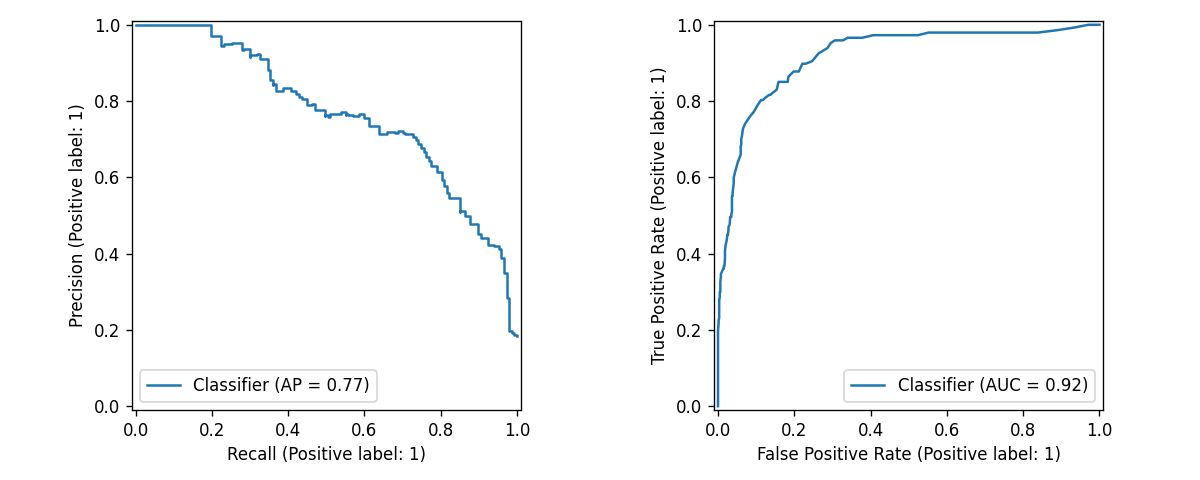

,feature,importance
0,Passport,0.251185
1,Designation,0.219069
2,MaritalStatus,0.124242
3,Age,0.106139
4,CityTier,0.083735
5,PreferredPropertyStar,0.073076
6,Occupation,0.069419
7,NumberOfTrips,0.066450
8,Gender,0.048911
9,MonthlyIncome,0.047511


**Post Interaction**

,Predicted no,Predicted yes
Actual no,598,58
Actual yes,23,124


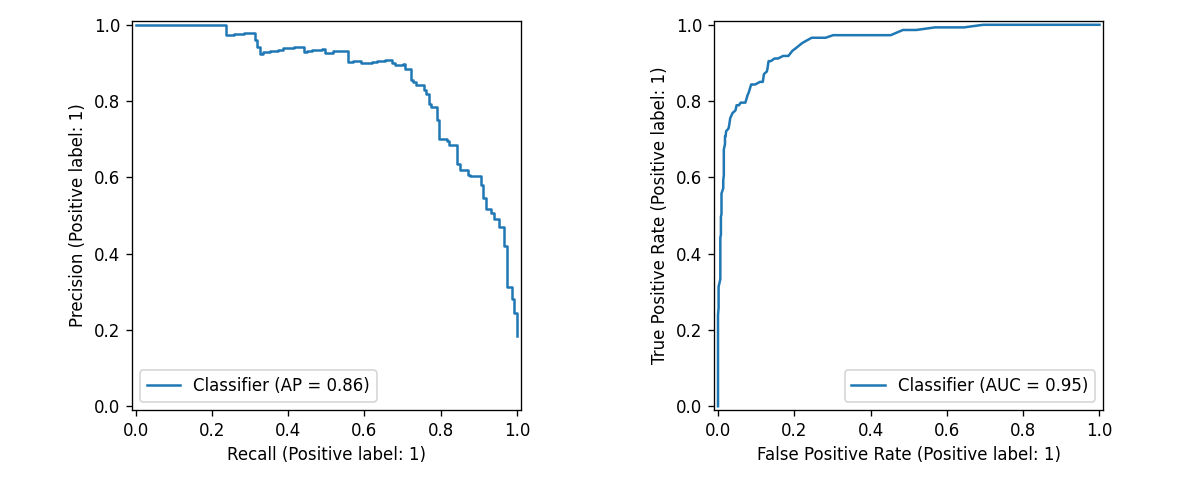

,feature,importance
0,Passport,0.233705
1,Designation,0.098895
2,MaritalStatus,0.083025
3,CityTier,0.079832
4,DurationOfPitch,0.077589
5,Age,0.070053
6,ProductPitched,0.056690
7,MonthlyIncome,0.052630
8,PreferredPropertyStar,0.050273
9,PitchSatisfactionScore,0.044373


# Submission Evidence and Rubric Mapping

The course announcement permits GitHub + GitHub Actions + Streamlit Community Cloud as an equivalent end-to-end workflow. This project deliberately uses that alternative; Hugging Face-specific rubric steps map to the outcomes below.

| Criterion | Points | Equivalent implementation and evidence |
|---|---:|---|
| Data registration | 3 | Master repository with `data/tourism.csv`; Git commit history and `data/manifest.json` register the snapshot and SHA-256. |
| Data preparation | 7 | Shared data module loads the registered checkout, validates/cleans, removes IDs/duplicates, saves group-exclusive train/test CSVs and fold manifest; Actions publishes outputs. |
| Model building and tracking | 13 | Random Forest/XGBoost grids for both stages; MLflow child runs log every parameter combination; full CV tables, selected thresholds and held-out reports; best models registered in GitHub Releases. |
| Deployment | 11 | Dockerfile, pinned deployment requirements, model-registry download/integrity checks, Streamlit DataFrame input, and `scripts/deploy.py` hosting/publishing script. |
| GitHub Actions MLOps | 15 | `.github/workflows/pipeline.yml`: checks, preparation, tuning, evaluation, notebook, Docker verification, versioned release, automatic generated main updates, and tested code promotion to `streamlit`. |
| Output evaluation | 4 | Repository/workflow/app links plus genuine screenshots listed below. Live evidence remains pending until publication and browser setup succeed. |
| Notebook quality | 7 | Structured EDA and explanation, commented shared pipeline calls, executed model/search results and output evaluation; reproducible repository layout. |
| **Total** | **60** | **Platform substitution follows the supplied course clarification.** |

## Links

- Configured GitHub repository: https://github.com/zfaida459-sudo/wellness_tourism_package_system
- Workflow page: https://github.com/zfaida459-sudo/wellness_tourism_package_system/actions/workflows/pipeline.yml
- Model releases: https://github.com/zfaida459-sudo/wellness_tourism_package_system/releases
- Successful workflow run: **Pending first published run.**
- Live Streamlit app: **Pending one-time Community Cloud connection and deployment.**

The workflow/release links are expected destinations, not evidence that the new implementation has already been pushed or executed on GitHub.

## Required Screenshots

- **Pending:** actual GitHub repository folder structure after source publication.
- **Pending:** successful full Actions run with all stage results visible.
- **Pending:** live Streamlit app showing a prediction and its model release; capture both stages when possible.

Place genuine captured images under `docs/screenshots/` and link them here after deployment. Never substitute a mock image, local screenshot or fabricated URL for required live evidence. The local app can be captured separately as development evidence.

## Initial Local Evaluation

4,011 cleaned records; 3,208 development rows and 803 test rows. Thresholds were selected on validation data, not the test labels.

| Stage | Model | Threshold | Test F1 | Test recall | Test average precision |
|---|---|---:|---:|---:|---:|
| Pre-contact | Random Forest | 0.32 | 0.719 | 0.741 | 0.768 |
| Post-interaction | Random Forest | 0.28 | 0.754 | 0.844 | 0.861 |

Historical tourism labels may not generalize to a new wellness offering. Data lacks event timing and does not establish causal marketing effects. Public sharing is limited to the authorized course dataset and project artifacts; uploaded app customer data is never saved.

Limitations:
- Historical tourism purchases are a proxy, not verified wellness-package outcomes.
- No timestamps establish whether interaction fields were measured before purchase.
- Travel preferences are assumed available in customer profiles before contact.
- Estimated model probabilities are not guaranteed calibrated probabilities.


In [85]:
# Compare measured performance without using test metrics to select models.
evaluation_rows = []
for stage, result in report['stages'].items():
    for partition, metrics in result['metrics'].items():
        evaluation_rows.append({
            'Stage': stage, 'Partition': partition,
            **{name: value for name, value in metrics.items() if name != 'confusion_matrix'},
        })
evaluation_table = pd.DataFrame(evaluation_rows)
display(evaluation_table.round(4))

for stage, result in report['stages'].items():
    display(Markdown(f"**{stage.replace('_', ' ').title()}**"))
    display(pd.DataFrame(result['metrics']['test']['confusion_matrix'],
                         index=['Actual no', 'Actual yes'], columns=['Predicted no', 'Predicted yes']))
    display(Image(filename=str(run_dir / f'{stage}-curves.png')))
    display(pd.read_csv(run_dir / f'{stage}-importance.csv').head(10))

# Submission evidence explicitly distinguishes local verification from live deployment.
display(Markdown(Path('docs/submission.md').read_text()))
print('Limitations:')
for limitation in report['limitations']:
    print('-', limitation)